In [1]:
# ============================================================
# GLOBAL COERCIVITY STRESS TEST (CLEAN COLAB BLOCK)
# ------------------------------------------------------------
# Shows:  D > 0  but  P ≈ 0
# ⇒ Any global coercivity inequality is false.
#
# This is an exact center-flux configuration on SU(2).
# ============================================================

import math
import torch

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ----------------------------
# SU(2) quaternion utilities
# q = (a,b,c,d), unit norm
# ----------------------------
def su2_mul(q1, q2):
    a1,b1,c1,d1 = q1.unbind(-1)
    a2,b2,c2,d2 = q2.unbind(-1)
    return torch.stack([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2,
    ], dim=-1)

def su2_conj(q):
    a,b,c,d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v):
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    a = torch.cos(theta)
    theta2 = theta * theta
    s_over = torch.where(
        theta > 1e-8,
        torch.sin(theta) / theta,
        1.0 - theta2/6.0 + theta2*theta2/120.0
    )
    return torch.cat([a, s_over * v], dim=-1)

# ----------------------------
# Lattice plaquette
# U shape: (L,L,L,L, 4, 4)
# ----------------------------
def plaquette(U, mu, nu):
    U_mu = U[..., mu, :]
    U_nu = U[..., nu, :]
    U_nu_xpmu = torch.roll(U_nu, shifts=-1, dims=mu)
    U_mu_xpnu = torch.roll(U_mu, shifts=-1, dims=nu)
    return su2_mul(
        su2_mul(
            su2_mul(U_mu, U_nu_xpmu),
            su2_conj(U_mu_xpnu)
        ),
        su2_conj(U_nu)
    )

def all_defects_flat(U):
    zs = []
    for mu in range(4):
        for nu in range(mu+1, 4):
            P = plaquette(U, mu, nu)
            zs.append(1.0 - P[..., 0])
    return torch.stack(zs, dim=0).reshape(-1)

# ----------------------------
# Exact center-flux config
# Works for even L
# ----------------------------
def build_center_flux(L):
    assert L % 2 == 0
    grids = torch.meshgrid(
        [torch.arange(L, device=device) for _ in range(4)],
        indexing="ij"
    )
    coords = torch.stack(grids, dim=-1)
    U = torch.zeros((L,L,L,L, 4, 4), device=device, dtype=torch.float64)

    for mu in range(4):
        if mu == 0:
            bit = torch.zeros((L,L,L,L), device=device, dtype=torch.int64)
        else:
            bit = coords[..., :mu].sum(dim=-1) % 2
        sign = 1.0 - 2.0 * bit.to(torch.float64)
        U[..., mu, 0] = sign

    return U

def verify_all_plaquettes_minusI(U, tol=1e-12):
    for mu in range(4):
        for nu in range(mu+1, 4):
            P = plaquette(U, mu, nu)
            if (P[...,0] + 1.0).abs().max() > tol:
                return False
            if P[...,1:].abs().max() > tol:
                return False
    return True

# ----------------------------
# Pairing estimator
# P = sum_p z_p * Γ(S, z_p)
# ----------------------------
@torch.no_grad()
def estimate_pairing(U, beta=6.0, eps=1e-4, mc=256, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)

    z0 = all_defects_flat(U)
    D = float(z0.sum().item())

    sumP = 0.0
    sumP2 = 0.0

    for _ in range(mc):
        Xi = torch.randn((*U.shape[:-1], 3), device=device, dtype=torch.float64, generator=g)
        Up = su2_mul(U, su2_exp( eps * Xi))
        Um = su2_mul(U, su2_exp(-eps * Xi))

        zp = all_defects_flat(Up)
        zm = all_defects_flat(Um)

        dz = (zp - zm) / (2.0 * eps)
        dS = beta * (zp.sum() - zm.sum()) / (2.0 * eps)

        Pk = (dz * z0).sum() * dS
        sumP  += float(Pk.item())
        sumP2 += float((Pk*Pk).item())

    mean = sumP / mc
    var  = max(0.0, (sumP2 - mc * mean * mean) / max(1, mc - 1))
    se   = math.sqrt(var / mc)

    return mean, se, D

# ============================================================
# RUN
# ============================================================
L = 4
beta = 6.0

U = build_center_flux(L)
ok = verify_all_plaquettes_minusI(U)
z = all_defects_flat(U)

P_hat, P_se, D = estimate_pairing(U, beta=beta)

print("\n=== CENTER-FLUX STRESS TEST ===")
print(f"L = {L}")
print(f"All plaquettes = -I ?  {ok}")
print(f"z_p unique values: {torch.unique(z).cpu().tolist()}")
print(f"D = sum_p z_p = {D:.6g}")
print(f"P ≈ {P_hat:.3e} ± {P_se:.3e}")
print(f"P / D ≈ {P_hat/D:.3e}")

print("\nConclusion:")
print("  D > 0 but P ≈ 0")
print("  ⇒ Any global coercivity inequality is false.")


[device] cpu

=== CENTER-FLUX STRESS TEST ===
L = 4
All plaquettes = -I ?  True
z_p unique values: [2.0]
D = sum_p z_p = 3072
P ≈ 5.024e-11 ± 4.494e-12
P / D ≈ 1.636e-14

Conclusion:
  D > 0 but P ≈ 0
  ⇒ Any global coercivity inequality is false.


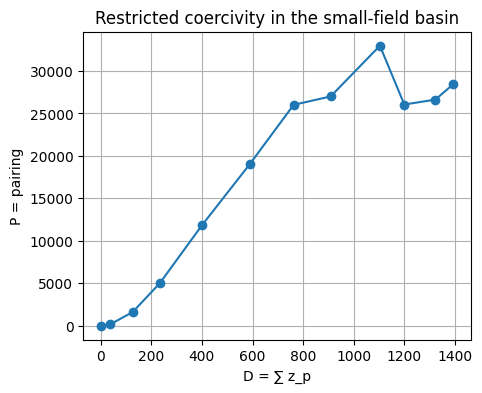

Ratios P/D:
σ=0.010  P/D=1.112e-01
σ=0.064  P/D=4.545e+00
σ=0.117  P/D=1.260e+01
σ=0.171  P/D=2.140e+01
σ=0.225  P/D=2.956e+01
σ=0.278  P/D=3.228e+01
σ=0.332  P/D=3.411e+01
σ=0.385  P/D=2.972e+01
σ=0.439  P/D=2.989e+01
σ=0.493  P/D=2.172e+01
σ=0.546  P/D=2.014e+01
σ=0.600  P/D=2.042e+01


In [2]:
# ============================================================
# RESTRICTED COERCIVITY DEMO (SMALL-FIELD BASIN)
# ------------------------------------------------------------
# Shows: for U = exp(σ Xi) with σ small,
#        P ≳ c D   (positive slope)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_small_field(L, sigma, device):
    Xi = torch.randn((L,L,L,L,4,3), device=device, dtype=torch.float64)
    return su2_exp(sigma * Xi)

@torch.no_grad()
def pairing_vs_badness_scan(L=4, sigmas=None, mc=128):
    if sigmas is None:
        sigmas = np.linspace(0.01, 0.6, 12)

    Ds, Ps = [], []

    for s in sigmas:
        U = sample_small_field(L, s, device)
        z = all_defects_flat(U)
        D = float(z.sum().item())
        P_hat, _, _ = estimate_pairing(U, beta=6.0, mc=mc)
        Ds.append(D)
        Ps.append(P_hat)

    return np.array(Ds), np.array(Ps), sigmas

# ---- run scan
Ds, Ps, sigmas = pairing_vs_badness_scan(L=4)

# ---- plot
plt.figure(figsize=(5,4))
plt.plot(Ds, Ps, "o-")
plt.xlabel("D = ∑ z_p")
plt.ylabel("P = pairing")
plt.title("Restricted coercivity in the small-field basin")
plt.grid(True)
plt.show()

print("Ratios P/D:")
for s, D, P in zip(sigmas, Ds, Ps):
    print(f"σ={s:0.3f}  P/D={P/D:0.3e}")


In [1]:
import math
import time
import numpy as np
import torch

# ============================================================
# Adversarial basin minimization for restricted quartic coercivity
#
# We minimize over U in K(r):  theta_max(U) <= r
#
#   ratio(U) = P_hat(U) / Z2(U),
#   Z2(U)    = sum_p z_p(U)^2,    z_p(U)=1 - a_p(U) for SU(2) quaternion plaquette P
#
# P_hat is computed via frozen MC directions Xi and symmetric finite differences:
#   D_X z_p ≈ (z_p(U e^{+eps Xi}) - z_p(U e^{-eps Xi})) / (2 eps)
#   D_X S   ≈ beta * (sum_p z_p(U e^{+eps Xi}) - sum_p z_p(U e^{-eps Xi})) / (2 eps)
#   P_hat   = E[ (D_X S) * sum_p z_p(U) (D_X z_p) ]
#
# This targets the basin-true coercivity candidate:
#   P(U) >= c(r) * sum_p z_p(U)^2  for U in K(r)
#
# ============================================================

CFG = dict(
    device="auto",          # "auto" | "cuda" | "cpu"
    L=8,                    # even; try 8, 12, (16 is heavy)
    beta=6.0,

    # Basin constraint: max plaquette angle theta <= r (r in radians)
    r=0.25,
    theta_slack=1e-3,       # allow tiny numerical slack in constraint check

    # Init amplitude for link algebra A (U=exp(A))
    sigma_init=0.02,

    # Batch of candidates optimized in parallel
    Ncand=8,

    # Optimization
    steps=200,
    lr=2e-2,
    adam_beta1=0.9,
    adam_beta2=0.999,

    # Finite difference + MC (optimization phase)
    eps_fd=1e-4,
    mc_opt=64,              # frozen directions count used during optimization (deterministic objective)
    mc_chunk_opt=8,         # chunk size for mc_opt (memory knob)

    # Evaluation phase (fresh MC, high precision)
    mc_eval=512,
    mc_chunk_eval=16,

    # Penalties / objective shaping
    penalty_theta=5e4,      # strong barrier for theta_max > r
    push_to_boundary=0.0,   # >0 encourages theta_max close to r (adds -push*theta_max to objective)

    # Numerical safety
    z2_min=1e-14,           # clamp in denominator
    clip_A=0.75,            # clamp |A_link| to this max (keeps exp map tame). Set None to disable.

    # Seeds / output
    seed=1234,
    out_npz="adversarial_basin_min.npz",
)

# --------------------------
# SU(2) quaternion ops
# --------------------------
def su2_mul(q1, q2):
    a1, b1, c1, d1 = q1.unbind(-1)
    a2, b2, c2, d2 = q2.unbind(-1)
    return torch.stack(
        [
            a1 * a2 - b1 * b2 - c1 * c2 - d1 * d2,
            a1 * b2 + b1 * a2 + c1 * d2 - d1 * c2,
            a1 * c2 - b1 * d2 + c1 * a2 + d1 * b2,
            a1 * d2 + b1 * c2 - c1 * b2 + d1 * a2,
        ],
        dim=-1,
    )

def su2_conj(q):
    a, b, c, d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v):
    # v (...,3) -> quaternion (...,4)
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    a = torch.cos(theta)
    theta2 = theta * theta
    s_over = torch.where(
        theta > 1e-8,
        torch.sin(theta) / theta.clamp_min(1e-30),
        1.0 - theta2 / 6.0 + (theta2 * theta2) / 120.0,
    )
    vec = s_over * v
    return torch.cat([a, vec], dim=-1)

# --------------------------
# Lattice ops (4D torus)
# U: (B, L,L,L,L, 4, 4)
# --------------------------
def roll4(x, mu, shift):
    # x shape (..., L,L,L,L, 4)
    start = x.ndim - 1 - 4
    return torch.roll(x, shifts=shift, dims=start + mu)

def plaquette(U, mu, nu):
    U_mu = U[..., mu, :]
    U_nu = U[..., nu, :]
    U_nu_xpmu = roll4(U_nu, mu, -1)
    U_mu_xpnu = roll4(U_mu, nu, -1)
    return su2_mul(
        su2_mul(su2_mul(U_mu, U_nu_xpmu), su2_conj(U_mu_xpnu)),
        su2_conj(U_nu),
    )

def all_defects(U):
    zs = []
    for mu in range(4):
        for nu in range(mu + 1, 4):
            P = plaquette(U, mu, nu)
            zs.append(1.0 - P[..., 0])  # z = 1 - a_p
    return torch.stack(zs, dim=0)  # (6, B, L,L,L,L) or (6, k, B, ...)

def compute_z2_thetaMax(U):
    # U: (B, L,L,L,L,4,4)
    z = all_defects(U)                      # (6,B,....)
    B = U.shape[0]
    zflat = z.reshape(6, B, -1).permute(1, 0, 2).reshape(B, -1)  # (B, Np)
    z2 = (zflat * zflat).sum(dim=1)         # (B,)
    zmax = zflat.max(dim=1).values          # (B,)
    # theta_max from a_p = 1 - z
    ap = 1.0 - z
    theta = torch.acos(torch.clamp(ap, -1.0, 1.0))
    theta_max = theta.reshape(6, B, -1).amax(dim=2).amax(dim=0)  # (B,)
    return zflat, z2, zmax, theta_max

# --------------------------
# Fixed MC bank for optimization
# Xi_bank: (K, B, L,L,L,L, 4, 3)
# --------------------------
def make_Xi_bank(K, B, L, device, dtype=torch.float32, seed=0):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    return torch.randn((K, B, L, L, L, L, 4, 3), device=device, dtype=dtype, generator=g)

# --------------------------
# Differentiable P_hat using frozen Xi_bank
# Returns P_hat (B,), optionally P_se if want_se=True
# --------------------------
def P_hat_from_bank(U, z0flat, beta, eps_fd, Xi_bank, mc_chunk, z2_min, want_se=False):
    device = U.device
    dtype = U.dtype
    K, B = Xi_bank.shape[0], Xi_bank.shape[1]
    U0 = U.unsqueeze(0)  # (1,B,...)

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)
    sumP2 = torch.zeros((B,), device=device, dtype=torch.float64) if want_se else None

    done = 0
    while done < K:
        k = min(mc_chunk, K - done)
        Xi = Xi_bank[done:done+k].to(dtype)               # (k,B,...,3)
        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)                           # (k,B,...,4,4)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)                              # (6,k,B,...)
        zm = all_defects(Um)

        # flatten to (k,B,Np)
        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)         # (k,B,Np)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)  # (k,B)

        inner = (dz * z0flat.unsqueeze(0)).sum(dim=2)      # (k,B)
        Pk = dS * inner                                     # (k,B)

        sumP += Pk.sum(dim=0).to(torch.float64)
        if want_se:
            sumP2 += (Pk * Pk).sum(dim=0).to(torch.float64)

        done += k

        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    P_hat = sumP / float(K)
    if not want_se:
        return P_hat, None

    mean = P_hat
    var = (sumP2 - (sumP * sumP) / float(K)) / float(max(1, K - 1))
    var = torch.clamp(var, min=0.0)
    P_se = torch.sqrt(var / float(K))
    return mean, P_se

# --------------------------
# High-precision evaluation (no grad): fresh MC directions generated on the fly
# --------------------------
@torch.no_grad()
def evaluate_candidate(U, beta, eps_fd, mc, mc_chunk, seed, z2_min):
    device = U.device
    B = U.shape[0]
    zflat, z2, zmax, theta_max = compute_z2_thetaMax(U)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)
    sumP2 = torch.zeros((B,), device=device, dtype=torch.float64)

    done = 0
    U0 = U.unsqueeze(0)
    while done < mc:
        k = min(mc_chunk, mc - done)
        Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(U.dtype)
        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)

        inner = (dz * zflat.unsqueeze(0)).sum(dim=2)
        Pk = dS * inner

        sumP += Pk.sum(dim=0).to(torch.float64)
        sumP2 += (Pk * Pk).sum(dim=0).to(torch.float64)

        done += k
        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    P_hat = sumP / float(mc)
    var = (sumP2 - (sumP * sumP) / float(mc)) / float(max(1, mc - 1))
    var = torch.clamp(var, min=0.0)
    P_se = torch.sqrt(var / float(mc))

    ratio = P_hat / torch.clamp(z2, min=z2_min)
    ratio_lcb = (P_hat - 2.0 * P_se) / torch.clamp(z2, min=z2_min)
    return dict(
        P_hat=P_hat.detach().cpu().numpy(),
        P_se=P_se.detach().cpu().numpy(),
        z2=z2.detach().cpu().numpy(),
        zmax=zmax.detach().cpu().numpy(),
        theta_max=theta_max.detach().cpu().numpy(),
        ratio=ratio.detach().cpu().numpy(),
        ratio_lcb=ratio_lcb.detach().cpu().numpy(),
    )

# --------------------------
# Main adversarial optimizer
# --------------------------
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if CFG["device"] == "auto" else torch.device(CFG["device"])
    print(f"[device] {device} {torch.cuda.get_device_name(0) if device.type=='cuda' else ''}")

    torch.manual_seed(int(CFG["seed"]))
    np.random.seed(int(CFG["seed"]))

    L = int(CFG["L"])
    assert L % 2 == 0, "Use even L."
    beta = float(CFG["beta"])
    r = float(CFG["r"])
    slack = float(CFG["theta_slack"])

    Ncand = int(CFG["Ncand"])
    sigma_init = float(CFG["sigma_init"])
    steps = int(CFG["steps"])
    lr = float(CFG["lr"])
    eps_fd = float(CFG["eps_fd"])
    mc_opt = int(CFG["mc_opt"])
    mc_chunk_opt = int(CFG["mc_chunk_opt"])
    mc_eval = int(CFG["mc_eval"])
    mc_chunk_eval = int(CFG["mc_chunk_eval"])
    penalty_theta = float(CFG["penalty_theta"])
    push = float(CFG["push_to_boundary"])
    z2_min = float(CFG["z2_min"])
    clip_A = CFG["clip_A"]
    out_npz = CFG.get("out_npz", None)

    # Candidate link algebra A: (B=L^4 configs) with A per link as R^3
    # A shape: (Ncand, L,L,L,L, 4, 3)
    A = (sigma_init * torch.randn((Ncand, L, L, L, L, 4, 3), device=device, dtype=torch.float32)).requires_grad_(True)

    # Frozen MC directions for optimization
    Xi_bank = make_Xi_bank(mc_opt, Ncand, L, device=device, dtype=torch.float32, seed=CFG["seed"] + 999)

    # Optimizer
    opt = torch.optim.Adam([A], lr=lr, betas=(CFG["adam_beta1"], CFG["adam_beta2"]))

    t0 = time.time()
    best = dict(obj=float("inf"))

    for it in range(steps):
        opt.zero_grad(set_to_none=True)

        # Optional clamp on |A_link| to keep exp stable
        if clip_A is not None:
            with torch.no_grad():
                norm = torch.linalg.norm(A, dim=-1, keepdim=True).clamp_min(1e-12)
                scale = torch.clamp(clip_A / norm, max=1.0)
                A.mul_(scale)

        # Build U = exp(A)
        U = su2_exp(A)  # (Ncand, L,L,L,L,4,4) in float32

        # Base metrics
        z0flat, z2, zmax, theta_max = compute_z2_thetaMax(U)

        # P_hat with frozen bank (differentiable)
        P_hat, _ = P_hat_from_bank(
            U=U,
            z0flat=z0flat,
            beta=beta,
            eps_fd=eps_fd,
            Xi_bank=Xi_bank,
            mc_chunk=mc_chunk_opt,
            z2_min=z2_min,
            want_se=False,
        )

        ratio = P_hat.to(z2.dtype) / torch.clamp(z2, min=z2_min)

        # Constraint penalty
        viol = torch.relu(theta_max - r)
        pen = penalty_theta * (viol * viol)

        # Optional boundary push (encourages theta_max close to r)
        obj = ratio + pen - push * theta_max

        # Scalar objective
        loss = obj.sum()
        loss.backward()
        opt.step()

        # Track best feasible candidate (by ratio, not objective-with-penalty)
        with torch.no_grad():
            feasible = (theta_max <= r + slack) & (z2 > z2_min)
            if feasible.any():
                rr = ratio.clone()
                rr[~feasible] = float("inf")
                j = int(torch.argmin(rr).item())
                val = float(rr[j].item())
                if val < best["obj"]:
                    best = dict(
                        obj=val,
                        it=it,
                        idx=j,
                        theta=float(theta_max[j].item()),
                        z2=float(z2[j].item()),
                        zmax=float(zmax[j].item()),
                    )

        if (it % 10 == 0) or (it == steps - 1):
            with torch.no_grad():
                feasible_cnt = int(((theta_max <= r + slack) & (z2 > z2_min)).sum().item())
                print(
                    f"[it {it:4d}] "
                    f"best_feasible_ratio={best['obj']:.6g} (idx={best.get('idx',-1)} theta={best.get('theta',float('nan')):.4f}) "
                    f"| feasible={feasible_cnt}/{Ncand} "
                    f"| theta_max: min/med/max={float(theta_max.min()):.4f}/{float(theta_max.median()):.4f}/{float(theta_max.max()):.4f}"
                )

        del U, z0flat, z2, zmax, theta_max, P_hat, ratio, viol, pen, obj, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

    wall = time.time() - t0
    print(f"\n[opt done] wall={wall/60:.2f} min")
    if best.get("idx", None) is None or not math.isfinite(best["obj"]):
        print("[warn] No feasible candidate found. Increase penalty_theta or reduce sigma_init / steps.")
        return

    # Rebuild best candidate U
    with torch.no_grad():
        if clip_A is not None:
            norm = torch.linalg.norm(A, dim=-1, keepdim=True).clamp_min(1e-12)
            scale = torch.clamp(clip_A / norm, max=1.0)
            A.mul_(scale)
        Ubest = su2_exp(A[best["idx"]:best["idx"]+1]).to(torch.float64)  # eval in float64

    # High-precision eval
    eval_seed = CFG["seed"] + 424242
    ev = evaluate_candidate(
        U=Ubest,
        beta=beta,
        eps_fd=eps_fd,
        mc=mc_eval,
        mc_chunk=mc_chunk_eval,
        seed=eval_seed,
        z2_min=z2_min,
    )
    print("\n=== BEST CANDIDATE (high-mc eval) ===")
    print(f"r={r} beta={beta} L={L}")
    print(f"ratio_mean   = {ev['ratio'][0]:.6g}")
    print(f"ratio_LCB(2σ)= {ev['ratio_lcb'][0]:.6g}")
    print(f"P_hat        = {ev['P_hat'][0]:.6e} ± {ev['P_se'][0]:.2e}")
    print(f"Z2           = {ev['z2'][0]:.6e}")
    print(f"zmax         = {ev['zmax'][0]:.6g}")
    print(f"theta_max    = {ev['theta_max'][0]:.6g}")

    if out_npz:
        np.savez_compressed(
            out_npz,
            CFG_text=str(CFG),
            best_it=np.int32(best["it"]),
            best_ratio_opt=np.float64(best["obj"]),
            best_theta_opt=np.float64(best["theta"]),
            eval_seed=np.int64(eval_seed),
            eval_ratio=np.float64(ev["ratio"][0]),
            eval_ratio_lcb=np.float64(ev["ratio_lcb"][0]),
            eval_P_hat=np.float64(ev["P_hat"][0]),
            eval_P_se=np.float64(ev["P_se"][0]),
            eval_Z2=np.float64(ev["z2"][0]),
            eval_zmax=np.float64(ev["zmax"][0]),
            eval_theta_max=np.float64(ev["theta_max"][0]),
            A_best=A[best["idx"]].detach().cpu().numpy().astype(np.float32),
        )
        print(f"[saved] {out_npz}")

if __name__ == "__main__":
    main()


[device] cuda Tesla T4
[it    0] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=8/8 | theta_max: min/med/max=0.1793/0.1896/0.2085
[it   10] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.0289/1.0557/1.0702
[it   20] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.5605/1.5892/1.6170
[it   30] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.6961/1.7378/1.7644
[it   40] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.6820/1.7283/1.7625
[it   50] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.6370/1.6449/1.6859
[it   60] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.5293/1.5581/1.5852
[it   70] best_feasible_ratio=88.6451 (idx=2 theta=0.1949) | feasible=0/8 | theta_max: min/med/max=1.4239/1.4454/1.4819
[it   80] best_fe

In [2]:
import math
import time
import numpy as np
import torch

# ============================================================
# Adversarial basin minimization for restricted quartic coercivity
#
# Minimize over U in K(r): theta_max(U_p) <= r
#
#   ratio(U) = P_hat(U) / Z2(U),
#   Z2(U)    = sum_p z_p(U)^2,   z_p(U)=1 - a_p(U)
#
# P_hat estimated by frozen MC directions Xi_bank + symmetric finite differences.
# This script enforces feasibility by projection at every step and
# snapshots the best-feasible candidate (so eval is meaningful).
# ============================================================

CFG = dict(
    device="auto",          # "auto" | "cuda" | "cpu"
    L=8,                    # even
    beta=6.0,
    r=0.25,                 # basin radius in radians (SU(2) plaquette angle)
    theta_slack=1e-6,

    # init amplitude for link algebra A (U=exp(A))
    sigma_init=0.02,

    # optimize Ncand candidates in parallel
    Ncand=8,

    # optimization
    steps=200,
    lr=2e-2,
    adam_beta1=0.9,
    adam_beta2=0.999,

    # finite difference + MC bank (optimization phase)
    eps_fd=1e-4,
    mc_opt=64,              # frozen directions count
    mc_chunk_opt=8,

    # evaluation phase (fresh MC, high precision)
    mc_eval=512,
    mc_chunk_eval=16,

    # objective shaping
    push_to_boundary=0.0,   # >0 encourages theta_max close to r (adds -push*theta_max)
    z2_min=1e-14,

    # stability clamps
    clip_A_link=0.50,       # clamp |A_link| <= clip_A_link (radians) each step (None to disable)
    proj_iters=6,           # projection refinement iterations
    proj_safety=0.985,      # safety factor in projection scaling

    # seeds / output
    seed=1234,
    out_npz="adversarial_basin_min_FIXED.npz",
)

# --------------------------
# SU(2) quaternion ops
# --------------------------
def su2_mul(q1, q2):
    a1, b1, c1, d1 = q1.unbind(-1)
    a2, b2, c2, d2 = q2.unbind(-1)
    return torch.stack(
        [
            a1 * a2 - b1 * b2 - c1 * c2 - d1 * d2,
            a1 * b2 + b1 * a2 + c1 * d2 - d1 * c2,
            a1 * c2 - b1 * d2 + c1 * a2 + d1 * b2,
            a1 * d2 + b1 * c2 - c1 * b2 + d1 * a2,
        ],
        dim=-1,
    )

def su2_conj(q):
    a, b, c, d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v):
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    a = torch.cos(theta)
    theta2 = theta * theta
    s_over = torch.where(
        theta > 1e-8,
        torch.sin(theta) / theta.clamp_min(1e-30),
        1.0 - theta2 / 6.0 + (theta2 * theta2) / 120.0,
    )
    vec = s_over * v
    return torch.cat([a, vec], dim=-1)

# --------------------------
# Lattice ops (4D torus)
# U: (B, L,L,L,L, 4, 4)
# --------------------------
def roll4(x, mu, shift):
    # x: (..., L,L,L,L, 4)
    start = x.ndim - 1 - 4
    return torch.roll(x, shifts=shift, dims=start + mu)

def plaquette(U, mu, nu):
    U_mu = U[..., mu, :]
    U_nu = U[..., nu, :]
    U_nu_xpmu = roll4(U_nu, mu, -1)
    U_mu_xpnu = roll4(U_mu, nu, -1)
    return su2_mul(
        su2_mul(su2_mul(U_mu, U_nu_xpmu), su2_conj(U_mu_xpnu)),
        su2_conj(U_nu),
    )

def all_defects(U):
    zs = []
    for mu in range(4):
        for nu in range(mu + 1, 4):
            P = plaquette(U, mu, nu)
            zs.append(1.0 - P[..., 0])
    return torch.stack(zs, dim=0)  # (6, B, ...)

def compute_z2_thetaMax(U):
    # U: (B,L,L,L,L,4,4)
    z = all_defects(U)  # (6,B,L,L,L,L)
    B = U.shape[0]
    zflat = z.reshape(6, B, -1).permute(1, 0, 2).reshape(B, -1)   # (B,Np)
    z2 = (zflat * zflat).sum(dim=1)                               # (B,)
    zmax = zflat.max(dim=1).values                                 # (B,)
    ap = 1.0 - z                                                   # a_p = 1 - z
    theta = torch.acos(torch.clamp(ap, -1.0, 1.0))
    theta_max = theta.reshape(6, B, -1).amax(dim=2).amax(dim=0)     # (B,)
    return zflat, z2, zmax, theta_max

# --------------------------
# Frozen MC bank
# Xi_bank: (K, B, L,L,L,L, 4, 3)
# --------------------------
def make_Xi_bank(K, B, L, device, dtype=torch.float32, seed=0):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    return torch.randn((K, B, L, L, L, L, 4, 3), device=device, dtype=dtype, generator=g)

# --------------------------
# Differentiable P_hat using frozen Xi_bank (no SE here)
# --------------------------
def P_hat_from_bank(U, z0flat, beta, eps_fd, Xi_bank, mc_chunk):
    device = U.device
    dtype = U.dtype
    K, B = Xi_bank.shape[0], Xi_bank.shape[1]
    U0 = U.unsqueeze(0)  # (1,B,...)

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)

    done = 0
    while done < K:
        k = min(mc_chunk, K - done)
        Xi = Xi_bank[done:done + k].to(dtype)  # (k,B,...,3)

        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)  # (6,k,B,...)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)  # (k,B,Np)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)  # (k,B)

        inner = (dz * z0flat.unsqueeze(0)).sum(dim=2)  # (k,B)
        Pk = dS * inner                                 # (k,B)

        sumP += Pk.sum(dim=0).to(torch.float64)

        done += k
        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return sumP / float(K)

# --------------------------
# High-precision eval with fresh MC (returns ratio and 2σ LCB)
# --------------------------
@torch.no_grad()
def evaluate_candidate(U, beta, eps_fd, mc, mc_chunk, seed, z2_min):
    device = U.device
    B = U.shape[0]

    zflat, z2, zmax, theta_max = compute_z2_thetaMax(U)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)
    sumP2 = torch.zeros((B,), device=device, dtype=torch.float64)

    done = 0
    U0 = U.unsqueeze(0)
    while done < mc:
        k = min(mc_chunk, mc - done)
        Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(U.dtype)

        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)

        inner = (dz * zflat.unsqueeze(0)).sum(dim=2)
        Pk = dS * inner

        sumP += Pk.sum(dim=0).to(torch.float64)
        sumP2 += (Pk * Pk).sum(dim=0).to(torch.float64)

        done += k
        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    P_hat = sumP / float(mc)
    var = (sumP2 - (sumP * sumP) / float(mc)) / float(max(1, mc - 1))
    var = torch.clamp(var, min=0.0)
    P_se = torch.sqrt(var / float(mc))

    denom = torch.clamp(z2, min=z2_min)
    ratio = P_hat / denom
    ratio_lcb = (P_hat - 2.0 * P_se) / denom

    return dict(
        P_hat=float(P_hat[0].item()),
        P_se=float(P_se[0].item()),
        Z2=float(z2[0].item()),
        zmax=float(zmax[0].item()),
        theta_max=float(theta_max[0].item()),
        ratio=float(ratio[0].item()),
        ratio_lcb=float(ratio_lcb[0].item()),
    )

# --------------------------
# Projection: scale A per candidate until theta_max <= r
# --------------------------
@torch.no_grad()
def project_to_basin(A, r, clip_A_link=None, iters=6, safety=0.985):
    # A: (Ncand, L,L,L,L, 4, 3)
    if clip_A_link is not None:
        n = torch.linalg.norm(A, dim=-1, keepdim=True).clamp_min(1e-12)
        s = torch.clamp(clip_A_link / n, max=1.0)
        A.mul_(s)

    for _ in range(iters):
        U = su2_exp(A)
        _, _, _, theta_max = compute_z2_thetaMax(U)
        viol = theta_max > r
        if not bool(viol.any()):
            break
        s = (r / theta_max.clamp_min(1e-12)) * safety
        s = torch.clamp(s, max=1.0)
        A[viol] *= s[viol].view(-1, 1, 1, 1, 1, 1, 1)
        del U, theta_max, viol, s

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if CFG["device"] == "auto" else torch.device(CFG["device"])
    print(f"[device] {device} {torch.cuda.get_device_name(0) if device.type=='cuda' else ''}")

    torch.manual_seed(int(CFG["seed"]))
    np.random.seed(int(CFG["seed"]))

    L = int(CFG["L"])
    assert L % 2 == 0
    beta = float(CFG["beta"])
    r = float(CFG["r"])
    slack = float(CFG["theta_slack"])

    Ncand = int(CFG["Ncand"])
    sigma_init = float(CFG["sigma_init"])
    steps = int(CFG["steps"])
    lr = float(CFG["lr"])
    eps_fd = float(CFG["eps_fd"])

    mc_opt = int(CFG["mc_opt"])
    mc_chunk_opt = int(CFG["mc_chunk_opt"])
    mc_eval = int(CFG["mc_eval"])
    mc_chunk_eval = int(CFG["mc_chunk_eval"])

    push = float(CFG["push_to_boundary"])
    z2_min = float(CFG["z2_min"])

    clip_A_link = CFG["clip_A_link"]
    proj_iters = int(CFG["proj_iters"])
    proj_safety = float(CFG["proj_safety"])

    out_npz = CFG.get("out_npz", None)

    # Link algebra candidates
    A = (sigma_init * torch.randn((Ncand, L, L, L, L, 4, 3), device=device, dtype=torch.float32)).requires_grad_(True)

    # Frozen MC bank for deterministic optimization objective
    Xi_bank = make_Xi_bank(mc_opt, Ncand, L, device=device, dtype=torch.float32, seed=int(CFG["seed"]) + 999)

    opt = torch.optim.Adam([A], lr=lr, betas=(CFG["adam_beta1"], CFG["adam_beta2"]))

    # Initial projection into basin
    with torch.no_grad():
        project_to_basin(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety)

    best = dict(ratio=float("inf"))

    t0 = time.time()
    for it in range(steps):
        opt.zero_grad(set_to_none=True)

        # Build U and objective
        U = su2_exp(A)  # float32
        z0flat, z2, zmax, theta_max = compute_z2_thetaMax(U)

        P_hat = P_hat_from_bank(U, z0flat, beta=beta, eps_fd=eps_fd, Xi_bank=Xi_bank, mc_chunk=mc_chunk_opt)
        ratio = P_hat.to(z2.dtype) / torch.clamp(z2, min=z2_min)

        # Encourage boundary if desired (still projected)
        obj = ratio - push * theta_max
        loss = obj.sum()
        loss.backward()
        opt.step()

        # Project back to basin after every update
        with torch.no_grad():
            project_to_basin(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety)

            # Recompute feasibility + snapshot best
            U2 = su2_exp(A)
            z0flat2, z22, zmax2, theta_max2 = compute_z2_thetaMax(U2)
            P_hat2 = P_hat_from_bank(U2, z0flat2, beta=beta, eps_fd=eps_fd, Xi_bank=Xi_bank, mc_chunk=mc_chunk_opt)
            ratio2 = P_hat2.to(z22.dtype) / torch.clamp(z22, min=z2_min)

            feasible = (theta_max2 <= r + slack) & (z22 > z2_min)
            if bool(feasible.any()):
                rr = ratio2.clone()
                rr[~feasible] = float("inf")
                j = int(torch.argmin(rr).item())
                val = float(rr[j].item())
                if val < best["ratio"]:
                    best = dict(
                        ratio=val,
                        it=it,
                        idx=j,
                        theta=float(theta_max2[j].item()),
                        z2=float(z22[j].item()),
                        zmax=float(zmax2[j].item()),
                        A_best=A[j].detach().cpu().clone().numpy().astype(np.float32),
                    )

        if (it % 10 == 0) or (it == steps - 1):
            with torch.no_grad():
                U3 = su2_exp(A)
                _, _, _, th3 = compute_z2_thetaMax(U3)
                print(
                    f"[it {it:4d}] "
                    f"best_ratio={best['ratio']:.6g} (idx={best.get('idx',-1)} theta={best.get('theta',float('nan')):.4f}) "
                    f"| theta_max min/med/max={float(th3.min()):.4f}/{float(th3.median()):.4f}/{float(th3.max()):.4f}"
                )

        del U, z0flat, z2, zmax, theta_max, P_hat, ratio, obj, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

    wall = time.time() - t0
    print(f"\n[opt done] wall={wall/60:.2f} min")

    if not math.isfinite(best["ratio"]):
        print("[warn] no feasible candidate (unexpected with projection).")
        return

    # High-precision evaluation of the best snapshot
    A_best = torch.tensor(best["A_best"], device=device, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        Ubest = su2_exp(A_best).to(torch.float64)
    ev = evaluate_candidate(
        Ubest,
        beta=beta,
        eps_fd=eps_fd,
        mc=mc_eval,
        mc_chunk=mc_chunk_eval,
        seed=int(CFG["seed"]) + 424242,
        z2_min=z2_min,
    )

    print("\n=== BEST CANDIDATE (high-mc eval) ===")
    print(f"r={r} beta={beta} L={L}")
    print(f"ratio_mean   = {ev['ratio']:.6g}")
    print(f"ratio_LCB(2σ)= {ev['ratio_lcb']:.6g}")
    print(f"P_hat        = {ev['P_hat']:.6e} ± {ev['P_se']:.2e}")
    print(f"Z2           = {ev['Z2']:.6e}")
    print(f"zmax         = {ev['zmax']:.6g}")
    print(f"theta_max    = {ev['theta_max']:.6g}  (should be <= r)")

    if out_npz:
        np.savez_compressed(
            out_npz,
            CFG_text=str(CFG),
            best_it=np.int32(best["it"]),
            best_ratio_opt=np.float64(best["ratio"]),
            best_theta_opt=np.float64(best["theta"]),
            eval_ratio=np.float64(ev["ratio"]),
            eval_ratio_lcb=np.float64(ev["ratio_lcb"]),
            eval_P_hat=np.float64(ev["P_hat"]),
            eval_P_se=np.float64(ev["P_se"]),
            eval_Z2=np.float64(ev["Z2"]),
            eval_zmax=np.float64(ev["zmax"]),
            eval_theta_max=np.float64(ev["theta_max"]),
            A_best=best["A_best"],
        )
        print(f"[saved] {out_npz}")

if __name__ == "__main__":
    main()


[device] cuda Tesla T4
[it    0] best_ratio=16597.7 (idx=5 theta=0.2462) | theta_max min/med/max=0.2459/0.2462/0.2464
[it   10] best_ratio=-3483.54 (idx=6 theta=0.2463) | theta_max min/med/max=0.2462/0.2463/0.2463
[it   20] best_ratio=-7365.87 (idx=3 theta=0.2462) | theta_max min/med/max=0.2462/0.2462/0.2463
[it   30] best_ratio=-8412.88 (idx=4 theta=0.2462) | theta_max min/med/max=0.2462/0.2462/0.2463
[it   40] best_ratio=-8793.24 (idx=6 theta=0.2463) | theta_max min/med/max=nan/nan/nan
[it   50] best_ratio=-8793.24 (idx=6 theta=0.2463) | theta_max min/med/max=nan/nan/nan
[it   60] best_ratio=-9005.36 (idx=4 theta=0.2462) | theta_max min/med/max=nan/nan/nan
[it   70] best_ratio=-9154.88 (idx=4 theta=0.2462) | theta_max min/med/max=nan/nan/nan
[it   80] best_ratio=-9154.88 (idx=4 theta=0.2462) | theta_max min/med/max=nan/nan/nan
[it   90] best_ratio=-9154.88 (idx=4 theta=0.2462) | theta_max min/med/max=nan/nan/nan
[it  100] best_ratio=-9154.88 (idx=4 theta=0.2462) | theta_max min/med/m

In [3]:
import math
import time
import numpy as np
import torch

# ============================================================
# Adversarial basin minimization (v2, robust)
#
# Fixes:
# - Hard projection to basin EVERY step (handles NaNs safely)
# - Optimize a conservative objective: LCB = (P_hat - nsigma*P_se)/Z2
# - Prevents denominator gaming: uses z2_floor and adds tiny penalty for z2 too small
# - Snapshots best-feasible candidate and evaluates it with big MC at the end
#
# You can push on A100 by increasing: L, Ncand, steps, mc_opt, mc_eval.
# ============================================================

CFG = dict(
    device="auto",          # "auto" | "cuda" | "cpu"
    L=8,                    # even (try 12 on A100)
    beta=6.0,

    # Basin constraint: max plaquette angle theta <= r (r in radians)
    r=0.25,
    theta_slack=1e-6,

    # Init amplitude for link algebra A (U=exp(A))
    sigma_init=0.02,

    # Optimize Ncand candidates in parallel
    Ncand=8,

    # Optimization
    steps=250,
    lr=8e-3,
    adam_beta1=0.9,
    adam_beta2=0.999,
    grad_clip=1.0,

    # Finite difference + MC (optimization phase, frozen bank)
    eps_fd=1e-4,
    mc_opt=128,             # frozen directions (more = smoother gradients)
    mc_chunk_opt=8,

    # Conservative objective
    nsigma_opt=1.0,         # LCB uses (P_hat - nsigma_opt*SE) during optimization

    # Evaluation phase (fresh MC, high precision)
    mc_eval=1024,
    mc_chunk_eval=16,
    nsigma_eval=2.0,        # report LCB with 2σ at the end

    # Numerical safety
    z2_floor=1e-10,         # floor in denominator for optimization (avoid blow-ups)
    z2_min_eval=1e-14,      # floor for reporting only
    z2_penalty=1e-4,        # small penalty * (z2_floor/(z2+z2_floor)) to avoid z2->0 gaming

    # Projection knobs
    clip_A_link=0.40,       # clamp |A_link| <= this (radians)
    proj_iters=6,
    proj_safety=0.985,

    # Seeds / output
    seed=1234,
    out_npz="adversarial_basin_min_v2.npz",
)

# --------------------------
# SU(2) quaternion ops
# --------------------------
def su2_mul(q1, q2):
    a1, b1, c1, d1 = q1.unbind(-1)
    a2, b2, c2, d2 = q2.unbind(-1)
    return torch.stack(
        [
            a1 * a2 - b1 * b2 - c1 * c2 - d1 * d2,
            a1 * b2 + b1 * a2 + c1 * d2 - d1 * c2,
            a1 * c2 - b1 * d2 + c1 * a2 + d1 * b2,
            a1 * d2 + b1 * c2 - c1 * b2 + d1 * a2,
        ],
        dim=-1,
    )

def su2_conj(q):
    a, b, c, d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v):
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    a = torch.cos(theta)
    theta2 = theta * theta
    s_over = torch.where(
        theta > 1e-8,
        torch.sin(theta) / theta.clamp_min(1e-30),
        1.0 - theta2 / 6.0 + (theta2 * theta2) / 120.0,
    )
    vec = s_over * v
    return torch.cat([a, vec], dim=-1)

# --------------------------
# Lattice ops (4D torus)
# U: (B, L,L,L,L, 4, 4)
# --------------------------
def roll4(x, mu, shift):
    start = x.ndim - 1 - 4
    return torch.roll(x, shifts=shift, dims=start + mu)

def plaquette(U, mu, nu):
    U_mu = U[..., mu, :]
    U_nu = U[..., nu, :]
    U_nu_xpmu = roll4(U_nu, mu, -1)
    U_mu_xpnu = roll4(U_mu, nu, -1)
    return su2_mul(
        su2_mul(su2_mul(U_mu, U_nu_xpmu), su2_conj(U_mu_xpnu)),
        su2_conj(U_nu),
    )

def all_defects(U):
    zs = []
    for mu in range(4):
        for nu in range(mu + 1, 4):
            P = plaquette(U, mu, nu)
            zs.append(1.0 - P[..., 0])
    return torch.stack(zs, dim=0)  # (6, B, ...)

def compute_z2_thetaMax(U):
    z = all_defects(U)  # (6,B,L,L,L,L)
    B = U.shape[0]
    zflat = z.reshape(6, B, -1).permute(1, 0, 2).reshape(B, -1)   # (B,Np)
    z2 = (zflat * zflat).sum(dim=1)                               # (B,)
    zmax = zflat.max(dim=1).values                                 # (B,)

    ap = 1.0 - z
    ap = torch.clamp(ap, -1.0, 1.0)
    theta = torch.acos(ap)
    theta_max = theta.reshape(6, B, -1).amax(dim=2).amax(dim=0)     # (B,)

    # sanitize (shouldn't happen, but keep projection stable)
    theta_max = torch.where(torch.isfinite(theta_max), theta_max, torch.full_like(theta_max, float("inf")))
    z2 = torch.where(torch.isfinite(z2), z2, torch.zeros_like(z2))
    zmax = torch.where(torch.isfinite(zmax), zmax, torch.zeros_like(zmax))
    zflat = torch.where(torch.isfinite(zflat), zflat, torch.zeros_like(zflat))
    return zflat, z2, zmax, theta_max

# --------------------------
# Frozen MC bank for deterministic optimization objective
# Xi_bank: (K, B, L,L,L,L, 4, 3)
# --------------------------
def make_Xi_bank(K, B, L, device, dtype=torch.float32, seed=0):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    return torch.randn((K, B, L, L, L, L, 4, 3), device=device, dtype=dtype, generator=g)

def P_hat_se_from_bank(U, z0flat, beta, eps_fd, Xi_bank, mc_chunk):
    device = U.device
    dtype = U.dtype
    K, B = Xi_bank.shape[0], Xi_bank.shape[1]
    U0 = U.unsqueeze(0)

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)
    sumP2 = torch.zeros((B,), device=device, dtype=torch.float64)

    done = 0
    while done < K:
        k = min(mc_chunk, K - done)
        Xi = Xi_bank[done:done + k].to(dtype)

        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)  # (6,k,B,...)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)  # (k,B,Np)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)  # (k,B)

        inner = (dz * z0flat.unsqueeze(0)).sum(dim=2)  # (k,B)
        Pk = dS * inner                                 # (k,B)

        sumP += Pk.sum(dim=0).to(torch.float64)
        sumP2 += (Pk * Pk).sum(dim=0).to(torch.float64)

        done += k
        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    mean = sumP / float(K)
    var = (sumP2 - (sumP * sumP) / float(K)) / float(max(1, K - 1))
    var = torch.clamp(var, min=0.0)
    se = torch.sqrt(var / float(K))
    return mean, se

@torch.no_grad()
def project_to_basin(A, r, clip_A_link, iters, safety):
    # clamp per-link |A|
    if clip_A_link is not None:
        n = torch.linalg.norm(A, dim=-1, keepdim=True).clamp_min(1e-12)
        s = torch.clamp(clip_A_link / n, max=1.0)
        A.mul_(s)

    for _ in range(iters):
        U = su2_exp(A)
        _, _, _, theta_max = compute_z2_thetaMax(U)
        viol = theta_max > r
        if not bool(viol.any()):
            break
        theta_safe = torch.where(torch.isfinite(theta_max), theta_max, torch.full_like(theta_max, float("inf")))
        s = (r / theta_safe.clamp_min(1e-12)) * safety
        s = torch.clamp(s, max=1.0)
        A[viol] *= s[viol].view(-1, 1, 1, 1, 1, 1, 1)
        del U, theta_max, viol, theta_safe, s
    del U

@torch.no_grad()
def evaluate_candidate(U, beta, eps_fd, mc, mc_chunk, seed, z2_min, nsigma):
    device = U.device
    B = U.shape[0]
    zflat, z2, zmax, theta_max = compute_z2_thetaMax(U)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    sumP = torch.zeros((B,), device=device, dtype=torch.float64)
    sumP2 = torch.zeros((B,), device=device, dtype=torch.float64)

    done = 0
    U0 = U.unsqueeze(0)
    while done < mc:
        k = min(mc_chunk, mc - done)
        Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(U.dtype)

        exp_p = su2_exp(eps_fd * Xi)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1, 2, 0, 3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * eps_fd)
        dS = beta * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * eps_fd)

        inner = (dz * zflat.unsqueeze(0)).sum(dim=2)
        Pk = dS * inner

        sumP += Pk.sum(dim=0).to(torch.float64)
        sumP2 += (Pk * Pk).sum(dim=0).to(torch.float64)

        done += k
        del Xi, exp_p, exp_m, Up, Um, zp, zm, zp_flat, zm_flat, dz, dS, inner, Pk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    P_hat = sumP / float(mc)
    var = (sumP2 - (sumP * sumP) / float(mc)) / float(max(1, mc - 1))
    var = torch.clamp(var, min=0.0)
    P_se = torch.sqrt(var / float(mc))

    denom = torch.clamp(z2, min=z2_min)
    ratio = P_hat / denom
    ratio_lcb = (P_hat - nsigma * P_se) / denom

    return dict(
        P_hat=float(P_hat[0].item()),
        P_se=float(P_se[0].item()),
        Z2=float(z2[0].item()),
        zmax=float(zmax[0].item()),
        theta_max=float(theta_max[0].item()),
        ratio=float(ratio[0].item()),
        ratio_lcb=float(ratio_lcb[0].item()),
    )

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if CFG["device"] == "auto" else torch.device(CFG["device"])
    print(f"[device] {device} {torch.cuda.get_device_name(0) if device.type=='cuda' else ''}")

    torch.manual_seed(int(CFG["seed"]))
    np.random.seed(int(CFG["seed"]))

    L = int(CFG["L"])
    assert L % 2 == 0
    beta = float(CFG["beta"])
    r = float(CFG["r"])
    slack = float(CFG["theta_slack"])

    Ncand = int(CFG["Ncand"])
    sigma_init = float(CFG["sigma_init"])
    steps = int(CFG["steps"])
    lr = float(CFG["lr"])
    eps_fd = float(CFG["eps_fd"])

    mc_opt = int(CFG["mc_opt"])
    mc_chunk_opt = int(CFG["mc_chunk_opt"])
    nsigma_opt = float(CFG["nsigma_opt"])

    mc_eval = int(CFG["mc_eval"])
    mc_chunk_eval = int(CFG["mc_chunk_eval"])
    nsigma_eval = float(CFG["nsigma_eval"])

    z2_floor = float(CFG["z2_floor"])
    z2_min_eval = float(CFG["z2_min_eval"])
    z2_penalty = float(CFG["z2_penalty"])

    clip_A_link = CFG["clip_A_link"]
    proj_iters = int(CFG["proj_iters"])
    proj_safety = float(CFG["proj_safety"])
    grad_clip = float(CFG["grad_clip"])

    out_npz = CFG.get("out_npz", None)

    # Candidates in link algebra
    A = (sigma_init * torch.randn((Ncand, L, L, L, L, 4, 3), device=device, dtype=torch.float32)).requires_grad_(True)

    # Frozen MC directions (deterministic objective)
    Xi_bank = make_Xi_bank(mc_opt, Ncand, L, device=device, dtype=torch.float32, seed=int(CFG["seed"]) + 999)

    opt = torch.optim.Adam([A], lr=lr, betas=(CFG["adam_beta1"], CFG["adam_beta2"]))

    # initial projection
    with torch.no_grad():
        project_to_basin(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety)

    best = dict(lcb=float("inf"))

    t0 = time.time()
    for it in range(steps):
        opt.zero_grad(set_to_none=True)

        U = su2_exp(A)  # float32
        z0flat, z2, zmax, theta_max = compute_z2_thetaMax(U)

        P_hat, P_se = P_hat_se_from_bank(U, z0flat, beta=beta, eps_fd=eps_fd, Xi_bank=Xi_bank, mc_chunk=mc_chunk_opt)

        denom = torch.clamp(z2, min=z2_floor)
        lcb = (P_hat - nsigma_opt * P_se) / denom
        loss = lcb.sum() + z2_penalty * (z2_floor / (z2 + z2_floor)).sum()

        loss.backward()
        torch.nn.utils.clip_grad_norm_([A], max_norm=grad_clip)
        opt.step()

        # project every step
        with torch.no_grad():
            project_to_basin(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety)

            # snapshot best feasible by LCB
            U2 = su2_exp(A)
            z0flat2, z22, zmax2, th2 = compute_z2_thetaMax(U2)
            P2, P2se = P_hat_se_from_bank(U2, z0flat2, beta=beta, eps_fd=eps_fd, Xi_bank=Xi_bank, mc_chunk=mc_chunk_opt)
            denom2 = torch.clamp(z22, min=z2_floor)
            lcb2 = (P2 - nsigma_opt * P2se) / denom2

            feasible = (th2 <= r + slack) & (z22 > 0)
            if bool(feasible.any()):
                rr = lcb2.clone()
                rr[~feasible] = float("inf")
                j = int(torch.argmin(rr).item())
                val = float(rr[j].item())
                if val < best["lcb"]:
                    best = dict(
                        lcb=val,
                        it=it,
                        idx=j,
                        theta=float(th2[j].item()),
                        z2=float(z22[j].item()),
                        zmax=float(zmax2[j].item()),
                        A_best=A[j].detach().cpu().clone().numpy().astype(np.float32),
                    )

        if (it % 10 == 0) or (it == steps - 1):
            with torch.no_grad():
                U3 = su2_exp(A)
                _, _, _, th3 = compute_z2_thetaMax(U3)
                print(
                    f"[it {it:4d}] best_lcb_opt={best['lcb']:.6g} (idx={best.get('idx',-1)} theta={best.get('theta',float('nan')):.4f}) "
                    f"| theta_max min/med/max={float(th3.min()):.4f}/{float(th3.median()):.4f}/{float(th3.max()):.4f}"
                )

        del U, z0flat, z2, zmax, theta_max, P_hat, P_se, denom, lcb, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

    wall = time.time() - t0
    print(f"\n[opt done] wall={wall/60:.2f} min")

    # evaluate best snapshot
    if not math.isfinite(best["lcb"]):
        print("[warn] no feasible snapshot captured (unexpected).")
        return

    A_best = torch.tensor(best["A_best"], device=device, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        Ubest = su2_exp(A_best).to(torch.float64)

    ev = evaluate_candidate(
        Ubest,
        beta=beta,
        eps_fd=eps_fd,
        mc=mc_eval,
        mc_chunk=mc_chunk_eval,
        seed=int(CFG["seed"]) + 424242,
        z2_min=z2_min_eval,
        nsigma=nsigma_eval,
    )

    print("\n=== BEST CANDIDATE (high-mc eval) ===")
    print(f"r={r} beta={beta} L={L}")
    print(f"ratio_mean        = {ev['ratio']:.6g}")
    print(f"ratio_LCB({nsigma_eval:.1f}σ) = {ev['ratio_lcb']:.6g}")
    print(f"P_hat             = {ev['P_hat']:.6e} ± {ev['P_se']:.2e}")
    print(f"Z2                = {ev['Z2']:.6e}")
    print(f"zmax              = {ev['zmax']:.6g}")
    print(f"theta_max         = {ev['theta_max']:.6g}  (<= r expected)")

    if out_npz:
        np.savez_compressed(
            out_npz,
            CFG_text=str(CFG),
            best_it=np.int32(best["it"]),
            best_lcb_opt=np.float64(best["lcb"]),
            best_theta_opt=np.float64(best["theta"]),
            eval_ratio=np.float64(ev["ratio"]),
            eval_ratio_lcb=np.float64(ev["ratio_lcb"]),
            eval_P_hat=np.float64(ev["P_hat"]),
            eval_P_se=np.float64(ev["P_se"]),
            eval_Z2=np.float64(ev["Z2"]),
            eval_zmax=np.float64(ev["zmax"]),
            eval_theta_max=np.float64(ev["theta_max"]),
            A_best=best["A_best"],
        )
        print(f"[saved] {out_npz}")

if __name__ == "__main__":
    main()


[device] cuda Tesla T4
[it    0] best_lcb_opt=2070.67 (idx=4 theta=0.2268) | theta_max min/med/max=0.2205/0.2268/0.2406
[it   10] best_lcb_opt=-2644.07 (idx=6 theta=0.2463) | theta_max min/med/max=0.2462/0.2463/0.2463
[it   20] best_lcb_opt=-6199.96 (idx=4 theta=0.2463) | theta_max min/med/max=0.2462/0.2463/0.2463
[it   30] best_lcb_opt=-7371.32 (idx=2 theta=0.2463) | theta_max min/med/max=0.2462/0.2462/0.2463
[it   40] best_lcb_opt=-7728.06 (idx=2 theta=0.2463) | theta_max min/med/max=0.2462/0.2462/0.2463
[it   50] best_lcb_opt=-7859.07 (idx=2 theta=0.2463) | theta_max min/med/max=0.2462/0.2463/0.2463
[it   60] best_lcb_opt=-8114.71 (idx=2 theta=0.2463) | theta_max min/med/max=0.2461/0.2463/0.2464
[it   70] best_lcb_opt=-8202.54 (idx=2 theta=0.2463) | theta_max min/med/max=0.2461/0.2463/0.2481
[it   80] best_lcb_opt=-8281.13 (idx=2 theta=0.2488) | theta_max min/med/max=0.2437/0.2463/0.2491
[it   90] best_lcb_opt=-8337.11 (idx=2 theta=0.2470) | theta_max min/med/max=0.2384/0.2465/0.249

In [9]:
# Robust small-field coercivity probe (NOTEBOOK-SAFE, FIXED)
# Full standalone block. No argparse. Runs in Colab/Jupyter.

import math
import time
from dataclasses import dataclass
from typing import Tuple

import torch

# ============================
# CONFIG (edit here)
# ============================

CONFIG = dict(
    L=6,
    beta=6.0,
    dtype="float32",          # "float32" or "float64"
    device="cuda" if torch.cuda.is_available() else "cpu",

    eps=1e-3,
    n_dirs=32,

    # random scan
    scan_sigma=0.02,
    scan_r=0.6,
    scan_n=64,

    # adversary
    run_adversary=True,
    adv_steps=200,
    adv_lr=1e-2,
    adv_c=1e-3,
    adv_sigma_init=0.02,

    seed=0,
)

# ============================
# SU(2) utilities
# ============================

def su2_mul(A, B):
    return A @ B

def su2_dag(U):
    return U.conj().transpose(-1, -2)

def su2_trace(U):
    return U[..., 0, 0] + U[..., 1, 1]

def su2_exp_from_a(a):
    device = a.device
    dtypec = torch.complex64 if a.dtype == torch.float32 else torch.complex128
    I = torch.eye(2, device=device, dtype=dtypec)

    norm = torch.linalg.norm(a, dim=-1, keepdim=True)
    ahat = a / torch.clamp(norm, min=1e-12)

    c = torch.cos(norm)[..., 0]
    s = torch.sin(norm)[..., 0]

    a1, a2, a3 = ahat.unbind(dim=-1)

    M = torch.empty(a.shape[:-1] + (2, 2), device=device, dtype=dtypec)
    M[..., 0, 0] = a3
    M[..., 1, 1] = -a3
    M[..., 0, 1] = a1 - 1j * a2
    M[..., 1, 0] = a1 + 1j * a2

    return c[..., None, None] * I + 1j * s[..., None, None] * M

def su2_plaq_angle(U):
    tr = su2_trace(U)
    c = (0.5 * tr.real).clamp(-1.0, 1.0)
    return torch.arccos(c)

def z_from_plaq(U):
    return 1.0 - 0.5 * su2_trace(U).real

# ============================
# Lattice
# ============================

@dataclass
class Lattice4D:
    L: int
    device: torch.device
    dtype: torch.dtype

    def __post_init__(self):
        # FIX: ensure it's a tuple, not an int
        self.shape = (self.L, self.L, self.L, self.L)

    def roll(self, x, dim, shift):
        return torch.roll(x, shifts=shift, dims=dim)

def make_links(lat, a):
    return su2_exp_from_a(a)

def plaquettes(lat, U):
    Ups = []
    for mu in range(4):
        for nu in range(mu + 1, 4):
            U_mu = U[mu]
            U_nu = U[nu]
            U_nu_shift = lat.roll(U_nu, mu, -1)   # x+mu
            U_mu_shift = lat.roll(U_mu, nu, -1)   # x+nu
            Up = su2_mul(
                su2_mul(U_mu, U_nu_shift),
                su2_mul(su2_dag(U_mu_shift), su2_dag(U_nu)),
            )
            Ups.append(Up)
    return torch.stack(Ups, dim=0)  # (6, L^4, 2,2)

def theta_max(lat, U):
    return su2_plaq_angle(plaquettes(lat, U)).max()

def action_and_z(lat, U, beta):
    Up = plaquettes(lat, U)
    z = z_from_plaq(Up)                 # (6, L^4)
    S = beta * z.sum()
    Z2 = (z * z).sum()
    return S, z, Z2

# ============================
# P / Z2 estimator
# ============================

@torch.no_grad()
def estimate_ratio(lat, a, beta, eps, n_dirs, seed):
    torch.manual_seed(seed)
    U0 = make_links(lat, a)
    th = float(theta_max(lat, U0).item())
    S0, z0, Z2 = action_and_z(lat, U0, beta)

    Z2f = float(Z2.item())
    if Z2f < 1e-24:
        return float("nan"), float("nan"), Z2f, th

    acc = torch.zeros_like(z0)

    for _ in range(n_dirs):
        v = torch.randn_like(a)
        ap = a + eps * v
        am = a - eps * v

        Sp, zp, _ = action_and_z(lat, make_links(lat, ap), beta)
        Sm, zm, _ = action_and_z(lat, make_links(lat, am), beta)

        dS = (Sp - Sm) / (2 * eps)      # scalar
        dz = (zp - zm) / (2 * eps)      # tensor like z
        acc += dS * dz

    acc /= float(n_dirs)
    P = (z0 * acc).sum()
    return float((P / Z2).item()), float(P.item()), Z2f, th

# ============================
# Random scan
# ============================

@torch.no_grad()
def random_scan(lat):
    out = []
    for i in range(CONFIG["scan_n"]):
        a = CONFIG["scan_sigma"] * torch.randn(
            (4,) + lat.shape + (3,),
            device=lat.device,
            dtype=lat.dtype,
        )
        U = make_links(lat, a)
        th = float(theta_max(lat, U).item())
        if th <= CONFIG["scan_r"]:
            r, P, Z2, _ = estimate_ratio(
                lat, a, CONFIG["beta"], CONFIG["eps"], CONFIG["n_dirs"], CONFIG["seed"] + i
            )
            if math.isfinite(r):
                out.append((r, P, Z2, th))
    return out

# ============================
# Adversary (SPSA)
# ============================

@torch.no_grad()
def adversary(lat, target_min_Z2=1e-2):
    a = CONFIG["adv_sigma_init"] * torch.randn(
        (4,) + lat.shape + (3,),
        device=lat.device,
        dtype=lat.dtype,
    )

    best = dict(val=float("inf"), ratio=float("inf"), P=float("nan"), Z2=float("nan"), theta=float("nan"), step=-1)

    def obj(a_cur, seed):
        ratio, P, Z2, th = estimate_ratio(lat, a_cur, CONFIG["beta"], CONFIG["eps"], CONFIG["n_dirs"], seed)
        if not math.isfinite(ratio):
            return float("inf"), ratio, P, Z2, th
        # penalize tiny denominator gaming
        if Z2 < target_min_Z2:
            ratio = ratio + 10.0 * (target_min_Z2 / max(Z2, 1e-12))
        return float(ratio), ratio, P, Z2, th

    for t in range(CONFIG["adv_steps"]):
        # shrink to feasible if needed (true plaquette basin)
        th = float(theta_max(lat, make_links(lat, a)).item())
        if th > CONFIG["scan_r"]:
            a *= 0.95 * (CONFIG["scan_r"] / max(th, 1e-12))

        val0, r0, P0, Z20, th0 = obj(a, CONFIG["seed"] + 1000 + t)
        if val0 < best["val"]:
            best = dict(val=val0, ratio=r0, P=P0, Z2=Z20, theta=th0, step=t)

        delta = torch.sign(torch.randn_like(a))
        ap = a + CONFIG["adv_c"] * delta
        am = a - CONFIG["adv_c"] * delta

        # shrink ap/am to feasible
        for X in (ap, am):
            thx = float(theta_max(lat, make_links(lat, X)).item())
            if thx > CONFIG["scan_r"]:
                X *= 0.95 * (CONFIG["scan_r"] / max(thx, 1e-12))

        vp, *_ = obj(ap, CONFIG["seed"] + 2000 + t)
        vm, *_ = obj(am, CONFIG["seed"] + 3000 + t)

        ghat = ((vp - vm) / (2.0 * CONFIG["adv_c"])) * (1.0 / delta)

        # backtracking step to keep feasibility
        step = CONFIG["adv_lr"]
        accepted = False
        for _ in range(10):
            anew = a - step * ghat
            thn = float(theta_max(lat, make_links(lat, anew)).item())
            if thn <= CONFIG["scan_r"]:
                vn, *_ = obj(anew, CONFIG["seed"] + 4000 + t)
                if vn <= val0 + 1e-6:
                    a = anew
                    accepted = True
                    break
            step *= 0.5

        if t % max(1, CONFIG["adv_steps"] // 10) == 0 or t == CONFIG["adv_steps"] - 1:
            print(f"[it {t:4d}] ratio={r0: .6g}  P={P0: .3e}  Z2={Z20: .3e}  theta={th0: .4f}  {'ACCEPT' if accepted else 'REJECT'}")

    return best

# ============================
# RUN
# ============================

torch.manual_seed(CONFIG["seed"])
device = torch.device(CONFIG["device"])
dtype = torch.float32 if CONFIG["dtype"] == "float32" else torch.float64

lat = Lattice4D(CONFIG["L"], device, dtype)

print(f"[device] {device}  [dtype] {dtype}  [L] {CONFIG['L']}  [beta] {CONFIG['beta']}")

t0 = time.time()

scan = random_scan(lat)
print("\n=== RANDOM SCAN (PLAQUETTE-FEASIBLE) ===")
print("feasible samples:", len(scan), " / ", CONFIG["scan_n"])
if scan:
    ratios = torch.tensor([x[0] for x in scan])
    thetas = torch.tensor([x[3] for x in scan])
    Z2s = torch.tensor([x[2] for x in scan])
    print("ratio min/med/max:", float(ratios.min()), float(ratios.median()), float(ratios.max()))
    print("theta max among feasible:", float(thetas.max()))
    print("Z2  min/med/max:", float(Z2s.min()), float(Z2s.median()), float(Z2s.max()))
else:
    print("no feasible samples (lower scan_sigma or increase scan_r)")

if CONFIG["run_adversary"]:
    print("\n=== ADVERSARY (TRUE PLAQUETTE BASIN) ===")
    best = adversary(lat)
    print("\n=== BEST FOUND ===")
    print(best)

print(f"\n[done] wall={time.time()-t0:.2f}s")


[device] cuda  [dtype] torch.float32  [L] 6  [beta] 6.0

=== RANDOM SCAN (PLAQUETTE-FEASIBLE) ===
feasible samples: 64  /  64
ratio min/med/max: 50.65534591674805 101.22474670410156 35487.359375
theta max among feasible: 0.2143777757883072
Z2  min/med/max: 0.06907089054584503 0.07458671182394028 0.07909530401229858

=== ADVERSARY (TRUE PLAQUETTE BASIN) ===
[it    0] ratio= 79.7611  P= 5.870e+00  Z2= 7.359e-02  theta= 0.1909  ACCEPT
[it   20] ratio= 70.2356  P= 7.416e+02  Z2= 1.056e+01  theta= 0.5524  REJECT
[it   40] ratio= 96.3742  P= 1.018e+03  Z2= 1.056e+01  theta= 0.5524  REJECT
[it   60] ratio= 65.1903  P= 7.432e+02  Z2= 1.140e+01  theta= 0.5983  REJECT
[it   80] ratio= 72.557  P= 8.684e+02  Z2= 1.197e+01  theta= 0.5993  REJECT
[it  100] ratio= 62.0002  P= 7.421e+02  Z2= 1.197e+01  theta= 0.5993  REJECT
[it  120] ratio= 76.1182  P= 9.111e+02  Z2= 1.197e+01  theta= 0.5993  REJECT
[it  140] ratio= 78.989  P= 9.454e+02  Z2= 1.197e+01  theta= 0.5993  REJECT
[it  160] ratio= 72.1183  P

In [12]:
import math, time
import torch
from dataclasses import dataclass

# ---------------- CONFIG ----------------
CFG = dict(
    L=6,
    beta=6.0,
    dtype="float32",
    device="cuda" if torch.cuda.is_available() else "cpu",

    eps=1e-3,
    n_dirs=32,
    seed=0,

    # theta-bin scan
    n_samples=512,
    sigma=0.06,            # larger than 0.02 so we actually populate bins up to r
    r=0.6,
    nbins=12,

    # adversary repeats
    adv_restarts=8,
    adv_steps=120,
    adv_lr=1e-2,
    adv_c=1e-3,
    adv_sigma_init=0.04,
    target_min_Z2=1e-2,
)

# ---------------- SU(2) ----------------
def su2_mul(A,B): return A @ B
def su2_dag(U): return U.conj().transpose(-1,-2)
def su2_trace(U): return U[...,0,0] + U[...,1,1]

def su2_exp_from_a(a):
    device=a.device
    dtypec=torch.complex64 if a.dtype==torch.float32 else torch.complex128
    I=torch.eye(2,device=device,dtype=dtypec)

    norm=torch.linalg.norm(a,dim=-1,keepdim=True)
    ahat=a/torch.clamp(norm,min=1e-12)

    c=torch.cos(norm)[...,0]
    s=torch.sin(norm)[...,0]

    a1,a2,a3=ahat.unbind(dim=-1)
    M=torch.empty(a.shape[:-1]+(2,2),device=device,dtype=dtypec)
    M[...,0,0]=a3
    M[...,1,1]=-a3
    M[...,0,1]=a1-1j*a2
    M[...,1,0]=a1+1j*a2

    return c[...,None,None]*I + 1j*s[...,None,None]*M

def su2_plaq_angle(U):
    c=(0.5*su2_trace(U).real).clamp(-1.0,1.0)
    return torch.arccos(c)

def z_from_plaq(U):
    return 1.0 - 0.5*su2_trace(U).real

# ---------------- Lattice ----------------
@dataclass
class Lattice4D:
    L:int
    device:torch.device
    dtype:torch.dtype
    def __post_init__(self):
        self.shape=(self.L,self.L,self.L,self.L)
    def roll(self,x,dim,shift):
        return torch.roll(x,shifts=shift,dims=dim)

def make_links(lat,a):
    return su2_exp_from_a(a)

def plaquettes(lat,U):
    Ups=[]
    for mu in range(4):
        for nu in range(mu+1,4):
            U_mu=U[mu]
            U_nu=U[nu]
            U_nu_shift=lat.roll(U_nu,mu,-1)
            U_mu_shift=lat.roll(U_mu,nu,-1)
            Up=su2_mul(su2_mul(U_mu,U_nu_shift), su2_mul(su2_dag(U_mu_shift), su2_dag(U_nu)))
            Ups.append(Up)
    return torch.stack(Ups,dim=0)

def theta_max(lat,U):
    return su2_plaq_angle(plaquettes(lat,U)).max()

def action_and_z(lat,U,beta):
    Up=plaquettes(lat,U)
    z=z_from_plaq(Up)
    S=beta*z.sum()
    Z2=(z*z).sum()
    return S,z,Z2

@torch.no_grad()
def estimate_ratio(lat,a,beta,eps,n_dirs,seed):
    torch.manual_seed(seed)
    U0=make_links(lat,a)
    th=float(theta_max(lat,U0).item())
    S0,z0,Z2=action_and_z(lat,U0,beta)
    Z2f=float(Z2.item())
    if Z2f<1e-24: return float("nan"), float("nan"), Z2f, th

    acc=torch.zeros_like(z0)
    for _ in range(n_dirs):
        v=torch.randn_like(a)
        ap=a+eps*v
        am=a-eps*v
        Sp,zp,_=action_and_z(lat,make_links(lat,ap),beta)
        Sm,zm,_=action_and_z(lat,make_links(lat,am),beta)
        dS=(Sp-Sm)/(2*eps)
        dz=(zp-zm)/(2*eps)
        acc += dS*dz
    acc /= float(n_dirs)
    P=(z0*acc).sum()
    return float((P/Z2).item()), float(P.item()), Z2f, th

@torch.no_grad()
def spsa_adversary(lat,r,seed):
    torch.manual_seed(seed)
    a=CFG["adv_sigma_init"]*torch.randn((4,)+lat.shape+(3,),device=lat.device,dtype=lat.dtype)

    best=dict(val=float("inf"), ratio=float("inf"), P=float("nan"), Z2=float("nan"), theta=float("nan"), step=-1)

    def obj(a_cur,s):
        ratio,P,Z2,th=estimate_ratio(lat,a_cur,CFG["beta"],CFG["eps"],CFG["n_dirs"],s)
        if not math.isfinite(ratio): return float("inf"), ratio,P,Z2,th
        if Z2<CFG["target_min_Z2"]:
            ratio = ratio + 10.0*(CFG["target_min_Z2"]/max(Z2,1e-12))
        return float(ratio), ratio,P,Z2,th

    for t in range(CFG["adv_steps"]):
        th=float(theta_max(lat,make_links(lat,a)).item())
        if th>r: a *= 0.95*(r/max(th,1e-12))

        val0,rat0,P0,Z20,th0=obj(a,seed+1000+t)
        if val0<best["val"]:
            best=dict(val=val0, ratio=rat0, P=P0, Z2=Z20, theta=th0, step=t)

        delta=torch.sign(torch.randn_like(a))
        ap=a+CFG["adv_c"]*delta
        am=a-CFG["adv_c"]*delta
        for X in (ap,am):
            thx=float(theta_max(lat,make_links(lat,X)).item())
            if thx>r: X *= 0.95*(r/max(thx,1e-12))
        vp,*_=obj(ap,seed+2000+t)
        vm,*_=obj(am,seed+3000+t)

        ghat=((vp-vm)/(2.0*CFG["adv_c"]))*(1.0/delta)

        step=CFG["adv_lr"]
        for _ in range(10):
            anew=a-step*ghat
            thn=float(theta_max(lat,make_links(lat,anew)).item())
            if thn<=r:
                vn,*_=obj(anew,seed+4000+t)
                if vn<=val0+1e-6:
                    a=anew
                    break
            step *= 0.5

    return best

# ---------------- RUN ----------------
torch.manual_seed(CFG["seed"])
device=torch.device(CFG["device"])
dtype=torch.float32 if CFG["dtype"]=="float32" else torch.float64
lat=Lattice4D(CFG["L"],device,dtype)

print(f"[device] {device}  [dtype] {dtype}  [L] {CFG['L']}  [beta] {CFG['beta']}")

t0=time.time()

# 1) Theta-binned random scan
edges=torch.linspace(0.0, CFG["r"], CFG["nbins"]+1, device=device)
bin_min=[float("inf")]*CFG["nbins"]
bin_cnt=[0]*CFG["nbins"]

for i in range(CFG["n_samples"]):
    a=CFG["sigma"]*torch.randn((4,)+lat.shape+(3,),device=device,dtype=dtype)
    U=make_links(lat,a)
    th=float(theta_max(lat,U).item())
    if th<=CFG["r"]:
        ratio,P,Z2,_=estimate_ratio(lat,a,CFG["beta"],CFG["eps"],CFG["n_dirs"],CFG["seed"]+i)
        if math.isfinite(ratio):
            b=min(int((th/CFG["r"])*CFG["nbins"]), CFG["nbins"]-1)
            bin_cnt[b]+=1
            if ratio<bin_min[b]: bin_min[b]=ratio

print("\n=== THETA-BIN MIN RATIO (random scan) ===")
for b in range(CFG["nbins"]):
    lo=float(edges[b].item()); hi=float(edges[b+1].item())
    m=bin_min[b]
    c=bin_cnt[b]
    print(f"bin {b:02d}  theta∈[{lo:.3f},{hi:.3f}]  n={c:4d}  min(P/Z2)={m if m<float('inf') else float('nan'):.6g}")

# 2) Adversary restarts
print("\n=== ADVERSARY RESTARTS ===")
best_global=None
for k in range(CFG["adv_restarts"]):
    best=spsa_adversary(lat, CFG["r"], CFG["seed"]+9999+77*k)
    print(f"restart {k:02d}: best ratio={best['ratio']:.6g}  theta={best['theta']:.4f}  Z2={best['Z2']:.3e}  step={best['step']}")
    if best_global is None or best["ratio"]<best_global["ratio"]:
        best_global=best

print("\n=== BEST OVERALL ===")
print(best_global)
print(f"\n[done] wall={time.time()-t0:.2f}s")


[device] cuda  [dtype] torch.float32  [L] 6  [beta] 6.0

=== THETA-BIN MIN RATIO (random scan) ===
bin 00  theta∈[0.000,0.050]  n=   0  min(P/Z2)=nan
bin 01  theta∈[0.050,0.100]  n=   0  min(P/Z2)=nan
bin 02  theta∈[0.100,0.150]  n=   0  min(P/Z2)=nan
bin 03  theta∈[0.150,0.200]  n=   0  min(P/Z2)=nan
bin 04  theta∈[0.200,0.250]  n=   0  min(P/Z2)=nan
bin 05  theta∈[0.250,0.300]  n=   0  min(P/Z2)=nan
bin 06  theta∈[0.300,0.350]  n=   0  min(P/Z2)=nan
bin 07  theta∈[0.350,0.400]  n=   0  min(P/Z2)=nan
bin 08  theta∈[0.400,0.450]  n=   0  min(P/Z2)=nan
bin 09  theta∈[0.450,0.500]  n=   5  min(P/Z2)=68.1007
bin 10  theta∈[0.500,0.550]  n= 222  min(P/Z2)=41.7878
bin 11  theta∈[0.550,0.600]  n= 223  min(P/Z2)=47.9445

=== ADVERSARY RESTARTS ===
restart 00: best ratio=35.774  theta=0.3972  Z2=4.318e-01  step=14
restart 01: best ratio=39.5029  theta=0.5831  Z2=4.388e+00  step=36
restart 02: best ratio=41.4199  theta=0.5607  Z2=4.872e+00  step=104
restart 03: best ratio=44.3523  theta=0.5942 

KeyboardInterrupt: 

In [13]:
import math, time
import torch
from dataclasses import dataclass

# ---------------- CONFIG ----------------
CFG = dict(
    L=6,
    beta=6.0,
    dtype="float32",
    device="cuda" if torch.cuda.is_available() else "cpu",

    eps=1e-3,
    n_dirs=32,
    seed=0,

    r=0.6,
    nbins=12,
    per_bin=32,          # targeted samples per theta-bin
    safety=0.98,         # keep under bin upper edge

    # adversary repeats
    adv_restarts=8,
    adv_steps=160,
    adv_lr=1e-2,
    adv_c=1e-3,
    adv_sigma_init=0.04,
    target_min_Z2=1e-2,
)

# ---------------- SU(2) ----------------
def su2_mul(A,B): return A @ B
def su2_dag(U): return U.conj().transpose(-1,-2)
def su2_trace(U): return U[...,0,0] + U[...,1,1]

def su2_exp_from_a(a):
    device=a.device
    dtypec=torch.complex64 if a.dtype==torch.float32 else torch.complex128
    I=torch.eye(2,device=device,dtype=dtypec)
    norm=torch.linalg.norm(a,dim=-1,keepdim=True)
    ahat=a/torch.clamp(norm,min=1e-12)
    c=torch.cos(norm)[...,0]
    s=torch.sin(norm)[...,0]
    a1,a2,a3=ahat.unbind(dim=-1)
    M=torch.empty(a.shape[:-1]+(2,2),device=device,dtype=dtypec)
    M[...,0,0]=a3
    M[...,1,1]=-a3
    M[...,0,1]=a1-1j*a2
    M[...,1,0]=a1+1j*a2
    return c[...,None,None]*I + 1j*s[...,None,None]*M

def su2_plaq_angle(U):
    c=(0.5*su2_trace(U).real).clamp(-1.0,1.0)
    return torch.arccos(c)

def z_from_plaq(U):
    return 1.0 - 0.5*su2_trace(U).real

# ---------------- Lattice ----------------
@dataclass
class Lattice4D:
    L:int
    device:torch.device
    dtype:torch.dtype
    def __post_init__(self):
        self.shape=(self.L,self.L,self.L,self.L)
    def roll(self,x,dim,shift):
        return torch.roll(x,shifts=shift,dims=dim)

def make_links(lat,a):
    return su2_exp_from_a(a)

def plaquettes(lat,U):
    Ups=[]
    for mu in range(4):
        for nu in range(mu+1,4):
            U_mu=U[mu]
            U_nu=U[nu]
            U_nu_shift=lat.roll(U_nu,mu,-1)
            U_mu_shift=lat.roll(U_mu,nu,-1)
            Up=su2_mul(su2_mul(U_mu,U_nu_shift), su2_mul(su2_dag(U_mu_shift), su2_dag(U_nu)))
            Ups.append(Up)
    return torch.stack(Ups,dim=0)

def theta_max(lat,U):
    return su2_plaq_angle(plaquettes(lat,U)).max()

def action_and_z(lat,U,beta):
    Up=plaquettes(lat,U)
    z=z_from_plaq(Up)
    S=beta*z.sum()
    Z2=(z*z).sum()
    return S,z,Z2

@torch.no_grad()
def estimate_ratio(lat,a,beta,eps,n_dirs,seed):
    torch.manual_seed(seed)
    U0=make_links(lat,a)
    th=float(theta_max(lat,U0).item())
    S0,z0,Z2=action_and_z(lat,U0,beta)
    Z2f=float(Z2.item())
    if Z2f<1e-24: return float("nan"), float("nan"), Z2f, th
    acc=torch.zeros_like(z0)
    for _ in range(n_dirs):
        v=torch.randn_like(a)
        ap=a+eps*v
        am=a-eps*v
        Sp,zp,_=action_and_z(lat,make_links(lat,ap),beta)
        Sm,zm,_=action_and_z(lat,make_links(lat,am),beta)
        dS=(Sp-Sm)/(2*eps)
        dz=(zp-zm)/(2*eps)
        acc += dS*dz
    acc /= float(n_dirs)
    P=(z0*acc).sum()
    return float((P/Z2).item()), float(P.item()), Z2f, th

# ---------------- Targeted theta sampler ----------------
@torch.no_grad()
def sample_with_theta_target(lat, theta_target, seed):
    torch.manual_seed(seed)
    a0=torch.randn((4,)+lat.shape+(3,),device=lat.device,dtype=lat.dtype)
    th0=float(theta_max(lat,make_links(lat,a0)).item())
    if th0 < 1e-9:
        return a0, th0
    t = theta_target / th0
    a = t * a0
    th=float(theta_max(lat,make_links(lat,a)).item())
    return a, th

# ---------------- Adversary (SPSA) ----------------
@torch.no_grad()
def spsa_adversary(lat,r,seed):
    torch.manual_seed(seed)
    a=CFG["adv_sigma_init"]*torch.randn((4,)+lat.shape+(3,),device=lat.device,dtype=lat.dtype)
    best=dict(val=float("inf"), ratio=float("inf"), P=float("nan"), Z2=float("nan"), theta=float("nan"), step=-1)

    def obj(a_cur,s):
        ratio,P,Z2,th=estimate_ratio(lat,a_cur,CFG["beta"],CFG["eps"],CFG["n_dirs"],s)
        if not math.isfinite(ratio): return float("inf"), ratio,P,Z2,th
        if Z2<CFG["target_min_Z2"]:
            ratio = ratio + 10.0*(CFG["target_min_Z2"]/max(Z2,1e-12))
        return float(ratio), ratio,P,Z2,th

    for t in range(CFG["adv_steps"]):
        th=float(theta_max(lat,make_links(lat,a)).item())
        if th>r: a *= 0.95*(r/max(th,1e-12))

        val0,rat0,P0,Z20,th0=obj(a,seed+1000+t)
        if val0<best["val"]:
            best=dict(val=val0, ratio=rat0, P=P0, Z2=Z20, theta=th0, step=t)

        delta=torch.sign(torch.randn_like(a))
        ap=a+CFG["adv_c"]*delta
        am=a-CFG["adv_c"]*delta
        for X in (ap,am):
            thx=float(theta_max(lat,make_links(lat,X)).item())
            if thx>r: X *= 0.95*(r/max(thx,1e-12))

        vp,*_=obj(ap,seed+2000+t)
        vm,*_=obj(am,seed+3000+t)
        ghat=((vp-vm)/(2.0*CFG["adv_c"]))*(1.0/delta)

        step=CFG["adv_lr"]
        for _ in range(10):
            anew=a-step*ghat
            thn=float(theta_max(lat,make_links(lat,anew)).item())
            if thn<=r:
                vn,*_=obj(anew,seed+4000+t)
                if vn<=val0+1e-6:
                    a=anew
                    break
            step *= 0.5

    return best

# ---------------- RUN ----------------
torch.manual_seed(CFG["seed"])
device=torch.device(CFG["device"])
dtype=torch.float32 if CFG["dtype"]=="float32" else torch.float64
lat=Lattice4D(CFG["L"],device,dtype)

print(f"[device] {device}  [dtype] {dtype}  [L] {CFG['L']}  [beta] {CFG['beta']}")

t0=time.time()

edges=torch.linspace(0.0, CFG["r"], CFG["nbins"]+1, device=device)
bin_min=[float("inf")]*CFG["nbins"]
bin_med=[]
bin_cnt=[0]*CFG["nbins"]

print("\n=== TARGETED THETA-BIN SCAN ===")
for b in range(CFG["nbins"]):
    lo=float(edges[b].item()); hi=float(edges[b+1].item())
    theta_t = CFG["safety"] * (0.5*(lo+hi))
    ratios=[]
    Z2s=[]
    thetas=[]
    for j in range(CFG["per_bin"]):
        a, th = sample_with_theta_target(lat, theta_t, CFG["seed"] + 10_000 + 1000*b + j)
        # enforce <= hi just in case
        if th > hi:
            a *= (hi/max(th,1e-12))*0.999
            th=float(theta_max(lat,make_links(lat,a)).item())
        ratio,P,Z2,th2 = estimate_ratio(lat,a,CFG["beta"],CFG["eps"],CFG["n_dirs"],CFG["seed"] + 20_000 + 1000*b + j)
        if math.isfinite(ratio):
            ratios.append(ratio); Z2s.append(Z2); thetas.append(th2)
    bin_cnt[b]=len(ratios)
    if ratios:
        rmin=min(ratios)
        rmed=float(torch.tensor(ratios,device="cpu").median().item())
        zmed=float(torch.tensor(Z2s,device="cpu").median().item())
        tmed=float(torch.tensor(thetas,device="cpu").median().item())
        bin_min[b]=rmin
        print(f"bin {b:02d} theta∈[{lo:.3f},{hi:.3f}] n={len(ratios):3d}  theta_med={tmed:.4f}  Z2_med={zmed:.3e}  ratio_min/med={rmin:.6g}/{rmed:.6g}")
    else:
        print(f"bin {b:02d} theta∈[{lo:.3f},{hi:.3f}] n=0")

print("\n=== ADVERSARY RESTARTS ===")
best_global=None
for k in range(CFG["adv_restarts"]):
    best=spsa_adversary(lat, CFG["r"], CFG["seed"]+9999+77*k)
    print(f"restart {k:02d}: best ratio={best['ratio']:.6g}  theta={best['theta']:.4f}  Z2={best['Z2']:.3e}  step={best['step']}")
    if best_global is None or best["ratio"]<best_global["ratio"]:
        best_global=best

print("\n=== BEST OVERALL ===")
print(best_global)
print(f"\n[done] wall={time.time()-t0:.2f}s")


[device] cuda  [dtype] torch.float32  [L] 6  [beta] 6.0

=== TARGETED THETA-BIN SCAN ===
bin 00 theta∈[0.000,0.050] n= 32  theta_med=0.0499  Z2_med=3.731e-04  ratio_min/med=64.1824/104.976
bin 01 theta∈[0.050,0.100] n= 32  theta_med=0.0999  Z2_med=6.430e-03  ratio_min/med=67.8347/110.613
bin 02 theta∈[0.100,0.150] n= 32  theta_med=0.1498  Z2_med=3.210e-02  ratio_min/med=46.3864/114.752
bin 03 theta∈[0.150,0.200] n= 32  theta_med=0.1996  Z2_med=9.985e-02  ratio_min/med=59.1178/99.9181
bin 04 theta∈[0.200,0.250] n= 32  theta_med=0.2503  Z2_med=2.418e-01  ratio_min/med=64.3701/113.513
bin 05 theta∈[0.250,0.300] n= 32  theta_med=0.2995  Z2_med=5.138e-01  ratio_min/med=48.6223/101.086
bin 06 theta∈[0.300,0.350] n= 32  theta_med=0.3511  Z2_med=9.963e-01  ratio_min/med=42.974/100.863
bin 07 theta∈[0.350,0.400] n= 32  theta_med=0.4015  Z2_med=1.622e+00  ratio_min/med=48.9333/109.481
bin 08 theta∈[0.400,0.450] n= 32  theta_med=0.4527  Z2_med=2.843e+00  ratio_min/med=60.2067/103.493
bin 09 theta

In [ ]:
import math
import time
import numpy as np
import torch

# ============================================================
# QUARTIC BASIN COERCIVITY — HARD MODE (OOM-SAFE, CHUNKED SGD)
# ------------------------------------------------------------
# This is the OOM-safe replacement for the previous hard-mode script.
#
# Key changes:
# - Uses small MC per iteration for gradients (mc_grad), NOT mc_train=128 with autograd graphs.
# - Uses candidate chunking for both gradient and projection.
# - Uses deterministic TRAIN/VAL seeded banks for selection (no-grad).
# - Uses high-MC fresh audit at the end.
#
# Objective:
#   ratio(U) = P_hat(U) / Z2(U)
#   Z2(U) = Σ_p z_p(U)^2,  z_p = 1 - a_p
#   P_hat(U) = E_X [ (D_X S)( Σ_p z_p(U) * D_X z_p(U) ) ],  S=β Σ_p z_p
#
# Basin constraint:
#   theta_max(U_p) <= r  (theta = acos(a_p))
# ============================================================

CFG = dict(
    device="auto",          # "auto" | "cuda" | "cpu"
    L=12,                   # HARD MODE (A100)
    beta=6.0,
    r_list=[0.25, 0.40],

    # candidates / restarts
    Ncand=64,
    restarts=4,

    # optimization
    steps=500,
    lr=6e-3,
    grad_clip=1.0,
    adam_beta1=0.9,
    adam_beta2=0.999,

    # finite difference
    eps_fd=1e-4,

    # SGD gradient estimator (small, to avoid autograd graph blow-up)
    mc_grad=2,              # per-iteration directions (keep tiny!)
    cand_chunk_grad=8,      # candidates per gradient chunk

    # VAL selection (no-grad, deterministic bank)
    mc_val=128,
    mc_chunk_val=4,
    val_every=25,
    cand_chunk_val=8,

    # final audit (fresh MC)
    mc_eval=2048,
    mc_chunk_eval=16,
    nsigma_eval=2.0,

    # init
    sigma_init=0.10,

    # basin projection
    clip_A_link=1.00,       # clamp per-link |A| <= this (radians)
    proj_iters=10,
    proj_safety=0.985,
    theta_slack=1e-6,
    cand_chunk_proj=8,

    # robustness
    z2_floor_opt=1e-10,
    z2_min_eval=1e-14,
    z2_penalty=1e-4,

    # candidate recovery
    reinit_sigma=0.05,
    reinit_absmax=50.0,     # if |A| max exceeds this, reinit candidate

    seed=1234,
    out_npz="quartic_basin_hardmode_L12_oomsafe.npz",
)

# --------------------------
# SU(2) quaternion ops
# --------------------------
def su2_mul(q1, q2):
    a1,b1,c1,d1 = q1.unbind(-1)
    a2,b2,c2,d2 = q2.unbind(-1)
    return torch.stack([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2,
    ], dim=-1)

def su2_conj(q):
    a,b,c,d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v):
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    theta2 = theta*theta
    s_over = torch.where(
        theta > 1e-8,
        torch.sin(theta)/theta.clamp_min(1e-30),
        1.0 - theta2/6.0 + (theta2*theta2)/120.0
    )
    return torch.cat([torch.cos(theta), s_over*v], dim=-1)

# --------------------------
# Lattice ops (4D torus)
# U: (B,L,L,L,L,4,4)
# --------------------------
def roll4(x, mu, shift):
    start = x.ndim - 1 - 4
    return torch.roll(x, shifts=shift, dims=start + mu)

def plaquette(U, mu, nu):
    U_mu = U[..., mu, :]
    U_nu = U[..., nu, :]
    U_nu_xpmu = roll4(U_nu, mu, -1)
    U_mu_xpnu = roll4(U_mu, nu, -1)
    return su2_mul(
        su2_mul(su2_mul(U_mu, U_nu_xpmu), su2_conj(U_mu_xpnu)),
        su2_conj(U_nu)
    )

def all_defects(U):
    zs = []
    for mu in range(4):
        for nu in range(mu+1, 4):
            P = plaquette(U, mu, nu)
            ap = torch.clamp(P[...,0], -1.0, 1.0)
            zs.append(1.0 - ap)
    return torch.stack(zs, dim=0)  # (6,B,...) or (6,k,B,...)

def compute_zflat_z2_zmax(U):
    z = all_defects(U)  # (6,B,L,L,L,L)
    B = U.shape[0]
    zflat = z.reshape(6, B, -1).permute(1,0,2).reshape(B, -1)
    z2 = (zflat*zflat).sum(dim=1)
    zmax = zflat.max(dim=1).values
    z2 = torch.where(torch.isfinite(z2), z2, torch.zeros_like(z2))
    zmax = torch.where(torch.isfinite(zmax), zmax, torch.zeros_like(zmax))
    zflat = torch.where(torch.isfinite(zflat), zflat, torch.zeros_like(zflat))
    return zflat, z2, zmax

def theta_max_plaq(U):
    z = all_defects(U)  # (6,B,...)
    B = U.shape[0]
    ap = torch.clamp(1.0 - z, -1.0, 1.0)
    th = torch.acos(ap)
    theta_max = th.reshape(6, B, -1).amax(dim=2).amax(dim=0)
    theta_max = torch.where(torch.isfinite(theta_max), theta_max, torch.full_like(theta_max, float("inf")))
    return theta_max

# --------------------------
# Candidate recovery + projection (chunked)
# --------------------------
@torch.no_grad()
def sanitize_and_reinit(A, gen, sigma, absmax):
    bad = ~torch.isfinite(A).all(dim=(1,2,3,4,5,6))
    if absmax is not None:
        too_big = A.abs().amax(dim=(1,2,3,4,5,6)) > float(absmax)
        bad = bad | too_big
    if bool(bad.any()):
        A[bad] = float(sigma) * torch.randn_like(A[bad], generator=gen)

@torch.no_grad()
def project_to_basin_chunked(A, r, clip_A_link, iters, safety, cand_chunk):
    Nc = A.shape[0]
    r = float(r)
    safety = float(safety)
    clip_A_link = float(clip_A_link) if clip_A_link is not None else None

    # per-link clamp
    if clip_A_link is not None:
        n = torch.linalg.norm(A, dim=-1, keepdim=True).clamp_min(1e-12)
        A.mul_(torch.clamp(clip_A_link / n, max=1.0))

    for _ in range(int(iters)):
        any_viol = False
        for s in range(0, Nc, cand_chunk):
            e = min(Nc, s + cand_chunk)
            U = su2_exp(A[s:e])
            th = theta_max_plaq(U)
            bad = torch.isinf(th)
            if bool(bad.any()):
                A[s:e][bad] *= 0.0
                U = su2_exp(A[s:e])
                th = theta_max_plaq(U)

            viol = th > r
            if bool(viol.any()):
                any_viol = True
                scale = (r / th.clamp_min(1e-12)) * safety
                scale = torch.clamp(scale, max=1.0)
                A[s:e][viol] *= scale[viol].view(-1,1,1,1,1,1,1).to(A.dtype)

        if not any_viol:
            break

# --------------------------
# Core estimator pieces
# --------------------------
def P_hat_sgd_chunk(U, z0flat, beta, eps_fd, k, seed):
    """
    Differentiable SGD estimator using k directions only.
    Returns P_hat approx (B,) as mean over k.
    """
    device = U.device
    dtype = U.dtype
    B = U.shape[0]
    U0 = U.unsqueeze(0)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(dtype)

    exp_p = su2_exp(float(eps_fd) * Xi)
    exp_m = su2_exp(-float(eps_fd) * Xi)

    Up = su2_mul(U0, exp_p)
    Um = su2_mul(U0, exp_m)

    zp = all_defects(Up)  # (6,k,B,...)
    zm = all_defects(Um)

    zp_flat = zp.reshape(6, k, B, -1).permute(1,2,0,3).reshape(k, B, -1)
    zm_flat = zm.reshape(6, k, B, -1).permute(1,2,0,3).reshape(k, B, -1)

    dz = (zp_flat - zm_flat) / (2.0 * float(eps_fd))
    dS = float(beta) * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * float(eps_fd))

    inner = (dz * z0flat.unsqueeze(0)).sum(dim=2)  # (k,B)
    Pk = dS * inner                                 # (k,B)

    return Pk.mean(dim=0).to(torch.float32)         # (B,)

@torch.no_grad()
def P_hat_from_seeded_bank_nograd(U, z0flat, beta, eps_fd, mc, mc_chunk, seed_bank):
    """
    No-grad deterministic bank evaluation (VAL).
    """
    device = U.device
    dtype = U.dtype
    B = U.shape[0]
    U0 = U.unsqueeze(0)

    sumP = torch.zeros((B,), device=device, dtype=torch.float32)
    done = 0
    mc = int(mc)
    mc_chunk = int(mc_chunk)

    while done < mc:
        k = min(mc_chunk, mc - done)
        g = torch.Generator(device=device)
        g.manual_seed(int(seed_bank + done))
        Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(dtype)

        exp_p = su2_exp(float(eps_fd) * Xi)
        exp_m = su2_exp(-float(eps_fd) * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, B, -1).permute(1,2,0,3).reshape(k, B, -1)
        zm_flat = zm.reshape(6, k, B, -1).permute(1,2,0,3).reshape(k, B, -1)

        dz = (zp_flat - zm_flat) / (2.0 * float(eps_fd))
        dS = float(beta) * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * float(eps_fd))
        inner = (dz * z0flat.unsqueeze(0)).sum(dim=2)
        Pk = dS * inner

        sumP += Pk.sum(dim=0).to(torch.float32)
        done += k

    return sumP / float(mc)

@torch.no_grad()
def evaluate_high_mc(U, beta, eps_fd, mc, mc_chunk, seed, z2_min, nsigma):
    device = U.device
    zflat, z2, zmax = compute_zflat_z2_zmax(U)
    theta_max = theta_max_plaq(U)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    sumP = 0.0
    sumP2 = 0.0

    done = 0
    U0 = U.unsqueeze(0)
    mc = int(mc)
    mc_chunk = int(mc_chunk)

    while done < mc:
        k = min(mc_chunk, mc - done)
        Xi = torch.randn((k, *U.shape[:5], 4, 3), device=device, dtype=torch.float32, generator=g).to(U.dtype)

        exp_p = su2_exp(float(eps_fd) * Xi)
        exp_m = su2_exp(-float(eps_fd) * Xi)

        Up = su2_mul(U0, exp_p)
        Um = su2_mul(U0, exp_m)

        zp = all_defects(Up)
        zm = all_defects(Um)

        zp_flat = zp.reshape(6, k, 1, -1).permute(1,2,0,3).reshape(k, 1, -1)
        zm_flat = zm.reshape(6, k, 1, -1).permute(1,2,0,3).reshape(k, 1, -1)

        dz = (zp_flat - zm_flat) / (2.0 * float(eps_fd))
        dS = float(beta) * (zp_flat.sum(dim=2) - zm_flat.sum(dim=2)) / (2.0 * float(eps_fd))

        inner = (dz * zflat.unsqueeze(0)).sum(dim=2)
        Pk = (dS * inner).squeeze(1)  # (k,)

        sumP += float(Pk.sum().item())
        sumP2 += float((Pk * Pk).sum().item())
        done += k

    P_hat = sumP / float(mc)
    var = (sumP2 - (sumP * sumP) / float(mc)) / float(max(1, mc - 1))
    var = max(0.0, var)
    P_se = math.sqrt(var / float(mc))

    Z2 = float(z2[0].item())
    denom = max(float(z2_min), Z2)
    ratio = P_hat / denom
    ratio_lcb = (P_hat - float(nsigma) * P_se) / denom

    return dict(
        P_hat=float(P_hat),
        P_se=float(P_se),
        Z2=float(Z2),
        zmax=float(zmax[0].item()),
        theta_max=float(theta_max[0].item()),
        ratio=float(ratio),
        ratio_lcb=float(ratio_lcb),
    )

# --------------------------
# One adversarial run for one radius (multiple restarts)
# --------------------------
def run_radius(dev, r, seed_base):
    L = int(CFG["L"])
    beta = float(CFG["beta"])
    Ncand = int(CFG["Ncand"])
    restarts = int(CFG["restarts"])
    steps = int(CFG["steps"])
    lr = float(CFG["lr"])
    grad_clip = float(CFG["grad_clip"])
    eps_fd = float(CFG["eps_fd"])

    mc_grad = int(CFG["mc_grad"])
    cand_chunk_grad = int(CFG["cand_chunk_grad"])

    mc_val = int(CFG["mc_val"])
    mc_chunk_val = int(CFG["mc_chunk_val"])
    cand_chunk_val = int(CFG["cand_chunk_val"])
    val_every = int(CFG["val_every"])

    z2_floor_opt = float(CFG["z2_floor_opt"])
    z2_penalty = float(CFG["z2_penalty"])

    sigma_init = float(CFG["sigma_init"])
    reinit_sigma = float(CFG["reinit_sigma"])
    reinit_absmax = float(CFG["reinit_absmax"])

    clip_A_link = float(CFG["clip_A_link"])
    proj_iters = int(CFG["proj_iters"])
    proj_safety = float(CFG["proj_safety"])
    cand_chunk_proj = int(CFG["cand_chunk_proj"])
    theta_slack = float(CFG["theta_slack"])

    global_best = dict(val=float("inf"))

    for rs in range(restarts):
        seed0 = int(seed_base + 777777 * rs)
        gen = torch.Generator(device=dev)
        gen.manual_seed(seed0)

        A = (sigma_init * torch.randn((Ncand, L, L, L, L, 4, 3), device=dev, dtype=torch.float32, generator=gen)).requires_grad_(True)
        opt = torch.optim.Adam([A], lr=lr, betas=(CFG["adam_beta1"], CFG["adam_beta2"]))

        with torch.no_grad():
            sanitize_and_reinit(A, gen, reinit_sigma, reinit_absmax)
            project_to_basin_chunked(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety, cand_chunk=cand_chunk_proj)

        best = dict(val=float("inf"), seed0=seed0)
        t0 = time.time()

        for it in range(steps):
            opt.zero_grad(set_to_none=True)
            sanitize_and_reinit(A, gen, reinit_sigma, reinit_absmax)

            # ---- gradient accumulation over candidate chunks (SGD in Xi) ----
            for s in range(0, Ncand, cand_chunk_grad):
                e = min(Ncand, s + cand_chunk_grad)

                A_chunk = A[s:e]
                U = su2_exp(A_chunk)
                z0flat, z2, _ = compute_zflat_z2_zmax(U)

                # small-k SGD estimator (deterministic seed schedule)
                P_hat = P_hat_sgd_chunk(U, z0flat, beta=beta, eps_fd=eps_fd, k=mc_grad, seed=seed0 + 10_000_000 + it*97 + s)

                denom = torch.clamp(z2, min=z2_floor_opt)
                ratio = P_hat / denom
                loss_chunk = ratio.sum() + z2_penalty * (z2_floor_opt / (z2 + z2_floor_opt)).sum()

                loss_chunk.backward()

            torch.nn.utils.clip_grad_norm_([A], max_norm=grad_clip)
            opt.step()

            with torch.no_grad():
                sanitize_and_reinit(A, gen, reinit_sigma, reinit_absmax)
                project_to_basin_chunked(A, r=r, clip_A_link=clip_A_link, iters=proj_iters, safety=proj_safety, cand_chunk=cand_chunk_proj)

            # ---- VAL selection ----
            if (it % val_every == 0) or (it == steps - 1):
                with torch.no_grad():
                    best_val = float("inf")
                    best_idx = -1
                    best_theta = float("nan")
                    best_z2 = float("nan")
                    best_zmax = float("nan")

                    for s in range(0, Ncand, cand_chunk_val):
                        e = min(Ncand, s + cand_chunk_val)
                        Uv = su2_exp(A[s:e])
                        z0v, z2v, zmaxv = compute_zflat_z2_zmax(Uv)
                        thv = theta_max_plaq(Uv)

                        P_val = P_hat_from_seeded_bank_nograd(
                            Uv, z0v, beta=beta, eps_fd=eps_fd,
                            mc=mc_val, mc_chunk=mc_chunk_val, seed_bank=seed0 + 200000
                        )
                        ratio_val = P_val / torch.clamp(z2v, min=z2_floor_opt)
                        feasible = (thv <= float(r) + theta_slack) & (z2v > 0) & torch.isfinite(ratio_val)
                        rv = ratio_val.clone()
                        rv[~feasible] = float("inf")

                        jloc = int(torch.argmin(rv).item())
                        vloc = float(rv[jloc].item())
                        if vloc < best_val:
                            best_val = vloc
                            best_idx = s + jloc
                            best_theta = float(thv[jloc].item())
                            best_z2 = float(z2v[jloc].item())
                            best_zmax = float(zmaxv[jloc].item())

                    if best_val < best["val"]:
                        best["val"] = best_val
                        best["it"] = it
                        best["idx"] = best_idx
                        best["theta"] = best_theta
                        best["z2"] = best_z2
                        best["zmax"] = best_zmax
                        best["A_best"] = A[best_idx].detach().cpu().numpy().astype(np.float32)

                    print(f"[r={r:.3g} rs={rs} it {it:4d}] best_val={best['val']:.6g} (theta={best.get('theta',float('nan')):.4f})")

        best["wall_s"] = time.time() - t0
        if best["val"] < global_best["val"]:
            global_best = best

        print(f"[r={r:.3g}] restart {rs}/{restarts-1} best_val={best['val']:.6g} wall={best['wall_s']/60:.2f} min")

    return global_best

# --------------------------
# Main
# --------------------------
def main():
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu") if CFG["device"] == "auto" else torch.device(CFG["device"])
    print("[device]", dev, (torch.cuda.get_device_name(0) if dev.type=="cuda" else ""))

    L = int(CFG["L"])
    assert L % 2 == 0

    beta = float(CFG["beta"])
    eps_fd = float(CFG["eps_fd"])
    base_seed = int(CFG["seed"])

    r_list = list(map(float, CFG["r_list"]))
    nR = len(r_list)

    out_r = np.array(r_list, dtype=np.float64)
    best_val_opt = np.full((nR,), np.nan, dtype=np.float64)
    best_theta_opt = np.full((nR,), np.nan, dtype=np.float64)
    audit_mean = np.full((nR,), np.nan, dtype=np.float64)
    audit_lcb = np.full((nR,), np.nan, dtype=np.float64)
    audit_theta = np.full((nR,), np.nan, dtype=np.float64)
    audit_zmax = np.full((nR,), np.nan, dtype=np.float64)
    audit_Z2 = np.full((nR,), np.nan, dtype=np.float64)
    audit_P = np.full((nR,), np.nan, dtype=np.float64)
    audit_Pse = np.full((nR,), np.nan, dtype=np.float64)
    wall_s = np.full((nR,), np.nan, dtype=np.float64)
    best_seed0 = np.full((nR,), -1, dtype=np.int64)

    for i, r in enumerate(r_list):
        print(f"\n=== RADIUS r={r} ===")
        best = run_radius(dev, r=r, seed_base=base_seed + 9999*i)

        # high-mc audit
        A_best = torch.tensor(best["A_best"], device=dev, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            project_to_basin_chunked(
                A_best, r=r, clip_A_link=float(CFG["clip_A_link"]),
                iters=int(CFG["proj_iters"]), safety=float(CFG["proj_safety"]),
                cand_chunk=1
            )
            Ubest = su2_exp(A_best).to(torch.float64)

        ev = evaluate_high_mc(
            Ubest,
            beta=beta,
            eps_fd=eps_fd,
            mc=int(CFG["mc_eval"]),
            mc_chunk=int(CFG["mc_chunk_eval"]),
            seed=base_seed + 424242 + i,
            z2_min=float(CFG["z2_min_eval"]),
            nsigma=float(CFG["nsigma_eval"]),
        )

        print(f"[AUDIT r={r}] mean={ev['ratio']:.6g}  LCB({CFG['nsigma_eval']:.1f}σ)={ev['ratio_lcb']:.6g}  theta={ev['theta_max']:.6g}  zmax={ev['zmax']:.6g}  Z2={ev['Z2']:.3e}")

        best_val_opt[i] = best["val"]
        best_theta_opt[i] = best["theta"]
        audit_mean[i] = ev["ratio"]
        audit_lcb[i] = ev["ratio_lcb"]
        audit_theta[i] = ev["theta_max"]
        audit_zmax[i] = ev["zmax"]
        audit_Z2[i] = ev["Z2"]
        audit_P[i] = ev["P_hat"]
        audit_Pse[i] = ev["P_se"]
        wall_s[i] = best["wall_s"]
        best_seed0[i] = best["seed0"]

    print("\n=== SUMMARY ===")
    for i, r in enumerate(r_list):
        print(f"r={r:<5}  LCB={audit_lcb[i]:.6g}  mean={audit_mean[i]:.6g}  theta={audit_theta[i]:.6g}  wall={wall_s[i]/60:.2f} min")

    out = CFG.get("out_npz", None)
    if out:
        np.savez_compressed(
            out,
            CFG_text=str(CFG),
            r_list=out_r,
            best_val_ratio_opt=best_val_opt,
            best_theta_opt=best_theta_opt,
            audit_ratio=audit_mean,
            audit_ratio_lcb=audit_lcb,
            audit_P_hat=audit_P,
            audit_P_se=audit_Pse,
            audit_Z2=audit_Z2,
            audit_zmax=audit_zmax,
            audit_theta=audit_theta,
            wall_s=wall_s,
            best_seed0=best_seed0,
        )
        print(f"[saved] {out}")

if __name__ == "__main__":
    main()


[device] cuda NVIDIA A100-SXM4-80GB

=== RADIUS r=0.25 ===
[r=0.25 rs=0 it    0] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it   25] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it   50] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it   75] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  100] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  125] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  150] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  175] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  200] best_val=64.0718 (theta=0.2462)
[r=0.25 rs=0 it  225] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  250] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  275] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  300] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  325] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  350] best_val=59.3023 (theta=0.2462)
[r=0.25 rs=0 it  375] best_val=43.5412 (theta=0.2463)
[r=0.25 rs=0 it  400] best_val=43.5412 (theta=0.2463)
[r=0.25 rs=0 it  425] b

KeyboardInterrupt: 